# Imports


In [4]:
%%capture
!cmd /c dependencies.bat 

In [1]:
import tensorflow as tf
print("Dispositivos GPU:", tf.config.list_physical_devices('GPU'))

Dispositivos GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
from tensorflow.python.client import device_lib

def get_available_gpus():
    local_device_protos = device_lib.list_local_devices()
    return [x.physical_device_desc for x in local_device_protos if x.device_type == 'GPU']

print(get_available_gpus())

['device: 0, name: DML, pci bus id: <undefined>', 'device: 1, name: DML, pci bus id: <undefined>']


In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
from collections import defaultdict
import pickle
import time

In [7]:
from skimage import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import multilabel_confusion_matrix, f1_score, classification_report

In [8]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping


In [9]:
from functions import *
import cv2

In [10]:
random.seed(42)
tf.random.set_seed(42)

# Data

In [11]:
path_sessions = "../capturas/capturas_256x256/SesionesCorrectas"

In [12]:
seq_session = {}

for entry in os.listdir(path_sessions):
    entry_path = os.path.join(path_sessions, entry)
    if os.path.isdir(entry_path) and entry.startswith("Session_"):
        image_files = [f for f in os.listdir(entry_path) if f.endswith(".png")]
        image_paths = [os.path.join(entry_path, f) for f in sorted(image_files)]
        seq_session[entry] = image_paths

In [13]:
print(seq_session['Session_001'][:10])

['../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0000.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0001.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0002.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0003.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0004.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0005.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0006.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0007.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0008.png', '../capturas/capturas_256x256/SesionesCorrectas\\Session_001\\capture_0009.png']


In [14]:
database = os.listdir(path_sessions)
csv = database[0]
csv_path = os.path.join(path_sessions, csv)
df_labels = pd.read_csv(csv_path, header = 0)

encoder = LabelEncoder()
df_labels['label_encoded'] = encoder.fit_transform(df_labels['label'])

n_classes = len(encoder.classes_)

df_labels['filename'] = df_labels['filename'].str.replace('\\', '/', regex=False)
label_dic = dict(zip(df_labels['filename'], df_labels['label_encoded']))

In [15]:
sessions = list(seq_session)
print(sessions)
random.shuffle(sessions)
print(sessions)

['Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007', 'Session_008', 'Session_009', 'Session_010']
['Session_008', 'Session_004', 'Session_003', 'Session_009', 'Session_006', 'Session_007', 'Session_010', 'Session_005', 'Session_001', 'Session_002']


In [15]:
# train, val, test split
train_sess = sessions[:7]
val_sess = sessions[7:8]
test_sess = sessions[8:]

print(f"training sessions: {train_sess}")
print(f"validation sessions: {val_sess}")
print(f"test sessions: {test_sess}")

training sessions: ['Session_008', 'Session_004', 'Session_003', 'Session_009', 'Session_006', 'Session_007', 'Session_010']
validation sessions: ['Session_005']
test sessions: ['Session_001', 'Session_002']


../capturas/capturas_256x256/SesionesCorrectas\Session_001\capture_0300.png


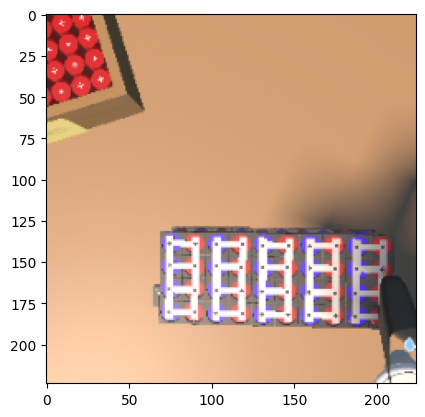

In [16]:
path = seq_session['Session_001'][300]
print(path)

size=(224, 224)
img = tf.io.read_file(path)
img = tf.image.decode_png(img, channels=3)
img = tf.image.resize(img, size)
img = img / 255.0
plt.imshow(img)
plt.show()

In [17]:
def ssim_metric(y_true, y_pred):
    # tf.image.ssim espera que las imágenes estén en rango [0, 1]
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

def psnr_metric(y_true, y_pred):
    return tf.reduce_mean(tf.image.psnr(y_true, y_pred, max_val=1.0))

*PSNR* (Peak Signal-to-Noise Ratio): mide la relación entre el los detalles nítidos de la imagen y el ruido que introduce la predicción. Se mide en decibelios, cuanto mayor sea el número mejor.  
- valores por encima de 25-30 dB se consideran buenos
  
*SSIM* (Structural Similarity Index): Evalía la imagen en ventanas locales buscando mantener la estructura, el contraste y la textura. Rango de -1 a 1, 1 significa imágenes idénticas.
- Si está por debajo de 0.85, el modelo está emborronando mucho los movimientos o ignorando las piezas nuevas.
- Si sube de 0.92 - 0.95, significa que el modelo está dibujando con muchísima precisión los cambios estructurales

In [16]:
img_size = 224

In [17]:
def session_window(sessions, seq_sessions_dic, label_dic, window_size):
    
    windows_x = []
    labels_y = []

    for session_name in sessions:
        img_paths = seq_sessions_dic[session_name]

        if window_size > len(img_paths):
            print(f"{session_name} no tiene menos frames que el tamaño de ventana.\n{session_name} no se tendrá en cuenta")
            continue
        
        for i in range(len(img_paths) - window_size):
            window_paths = img_paths[i:i+window_size]
            windows_x.append(window_paths)

            target_path = img_paths[i+window_size]
            sess_id = os.path.basename(os.path.dirname(target_path))
            file_name = os.path.basename(target_path)

            clave = f"{sess_id}/{file_name}"
            label = label_dic.get(clave)
            labels_y.append(label)

    return windows_x, labels_y

In [18]:
def load_imgs_for_window(window_paths, label):

    window_images = tf.map_fn(lambda x: load_img_ts(x, size=(img_size, img_size)), window_paths, fn_output_signature=tf.float32)

    return window_images, label

In [19]:
def create_ds(sessions_list, seq_session_dic, label_dic, window_size, batch_size, shuffle):
    
    X_paths, y_labels = session_window(sessions_list, seq_session_dic, label_dic, window_size)

    dataset = tf.data.Dataset.from_tensor_slices((X_paths, y_labels))

    dataset = dataset.map(load_imgs_for_window, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X_paths)) # shufle del orden de los grupos de ventanas, no de las imágenes de dentro de las ventanas
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE) 
    
    return dataset

In [20]:
window_size = 10
batch_size = 4

In [ ]:
train_ds = create_ds(train_sess, seq_session, label_dic, window_size, batch_size)
val_ds = create_ds(val_sess, seq_session, label_dic, window_size, batch_size)
test_ds = create_ds(test_sess, seq_session, label_dic, window_size, batch_size)

# Training and testing

## Pipeline

In [23]:
def training_pipeline_ts(model, train_ds, val_ds, test_ds, patience=3, epochs=20, lr=0.005):
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    
    lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=patience, verbose=1, min_lr=4e-10
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=patience*2, 
        verbose=1, 
        restore_best_weights=True
    )

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.MeanSquaredError(), # probar MeanAbsoluteError()
        metrics=['mae', ssim_metric, psnr_metric]
    )
        
    history = model.fit(
        train_ds, 
        epochs=epochs, 
        validation_data=val_ds, 
        callbacks=[lr_callback, early_stop]
    )

    print("\nEvaluando en Entrenamiento...")
    train_loss, train_mse, train_ssim, train_psnr = model.evaluate(train_ds, verbose=0)
    print("Evaluando en Test...")
    test_loss, test_mse, test_ssim, test_psnr = model.evaluate(test_ds, verbose=0)
    
    return test_mse, train_mse, train_loss, test_loss, train_ssim, test_ssim, train_psnr, test_psnr, history

## model 0

In [52]:
model_00 = Sequential([
   
    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True,
        input_shape=(window_size, img_size, img_size, 3)
    ),
    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=False
    ),
    Conv2D(
        filters=3,
        kernel_size=(3, 3),
        activation="sigmoid",
        padding="same"
    )
])

In [53]:
test_mse, train_mse, train_loss, test_loss, train_ssim, test_ssim, train_psnr, test_psnr, history = training_pipeline_ts(model_00, train_ds, val_ds, test_ds, lr=0.001)

print(f"Test mse: {test_mse}\nTrain mse: {train_mse}")
print(f"Test loss: {test_loss}\nTrain loss: {train_loss}")
print(f"Test ssim: {test_ssim}\nTrain ssim: {train_ssim}")
print(f"Test psnr: {test_psnr}\nTrain loss: {train_psnr}")

Epoch 1/20
352/352 [==============================] - 113s 305ms/step - loss: 0.0086 - mae: 0.0511 - ssim_metric: 0.8511 - psnr_metric: 22.1554 - val_loss: 0.0190 - val_mae: 0.1151 - val_ssim_metric: 0.7682 - val_psnr_metric: 17.2726 - lr: 0.0010
Epoch 2/20
352/352 [==============================] - 116s 328ms/step - loss: 0.0066 - mae: 0.0405 - ssim_metric: 0.8890 - psnr_metric: 23.6054 - val_loss: 0.0079 - val_mae: 0.0523 - val_ssim_metric: 0.8880 - val_psnr_metric: 21.8479 - lr: 0.0010
Epoch 3/20
352/352 [==============================] - 143s 405ms/step - loss: 0.0064 - mae: 0.0390 - ssim_metric: 0.8938 - psnr_metric: 23.8453 - val_loss: 0.0075 - val_mae: 0.0498 - val_ssim_metric: 0.8925 - val_psnr_metric: 22.2724 - lr: 0.0010
Epoch 4/20
352/352 [==============================] - 147s 417ms/step - loss: 0.0063 - mae: 0.0379 - ssim_metric: 0.8963 - psnr_metric: 23.9985 - val_loss: 0.0082 - val_mae: 0.0551 - val_ssim_metric: 0.8738 - val_psnr_metric: 21.7147 - lr: 0.0010
Epoch 5/20
3

1/1 [==============================] - 0s 471ms/step


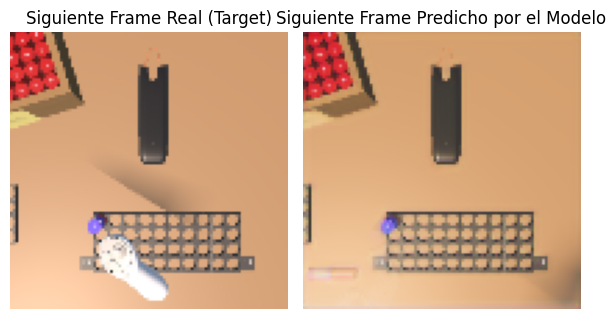

1/1 [==============================] - 0s 41ms/step


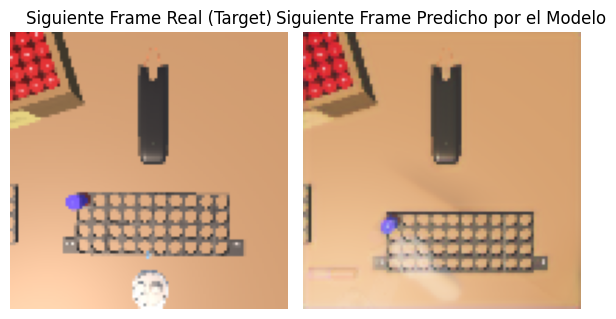

In [ ]:
for i in range():    
    for X_batch, y_batch in test_ds.take(1):
        
        ventana_prueba = X_batch[i]
        imagen_real = y_batch[i]
        
        input_modelo = np.expand_dims(ventana_prueba, axis=0)
        
        prediccion = model_00.predict(input_modelo)
        
        imagen_predicha = prediccion[0]
        
        fig, axes = plt.subplots(1, 2, figsize=(6, 4))
        
        # Imagen Real (Target)
        axes[0].imshow(imagen_real)
        axes[0].set_title("Siguiente Frame Real (Target)")
        axes[0].axis('off')
        
        # Imagen Predicha por el Modelo
        axes[1].imshow(imagen_predicha)
        axes[1].set_title("Siguiente Frame Predicho por el Modelo")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        break

In [61]:
def predict_next(model, session_paths, inicio, fin, n_steps):

    paths = session_paths[inicio:fin+1]

    if len(paths) < n_steps:
        print(f"El tramo seleccionado es demasiado corto")
        return
    
    last_n = paths[-n_steps:]

    last_n_imgs = [load_img_ts(p, size=(img_size, img_size)) for p in last_n]
    x = np.expand_dims(np.array(last_n_imgs), axis=0)

    pred = model.predict(x, verbose=0)

    return pred[0], np.array(last_n_imgs)      

In [27]:
print(test_sess)

['Session_001', 'Session_002']


Prediciendo imagen 10 de session_001


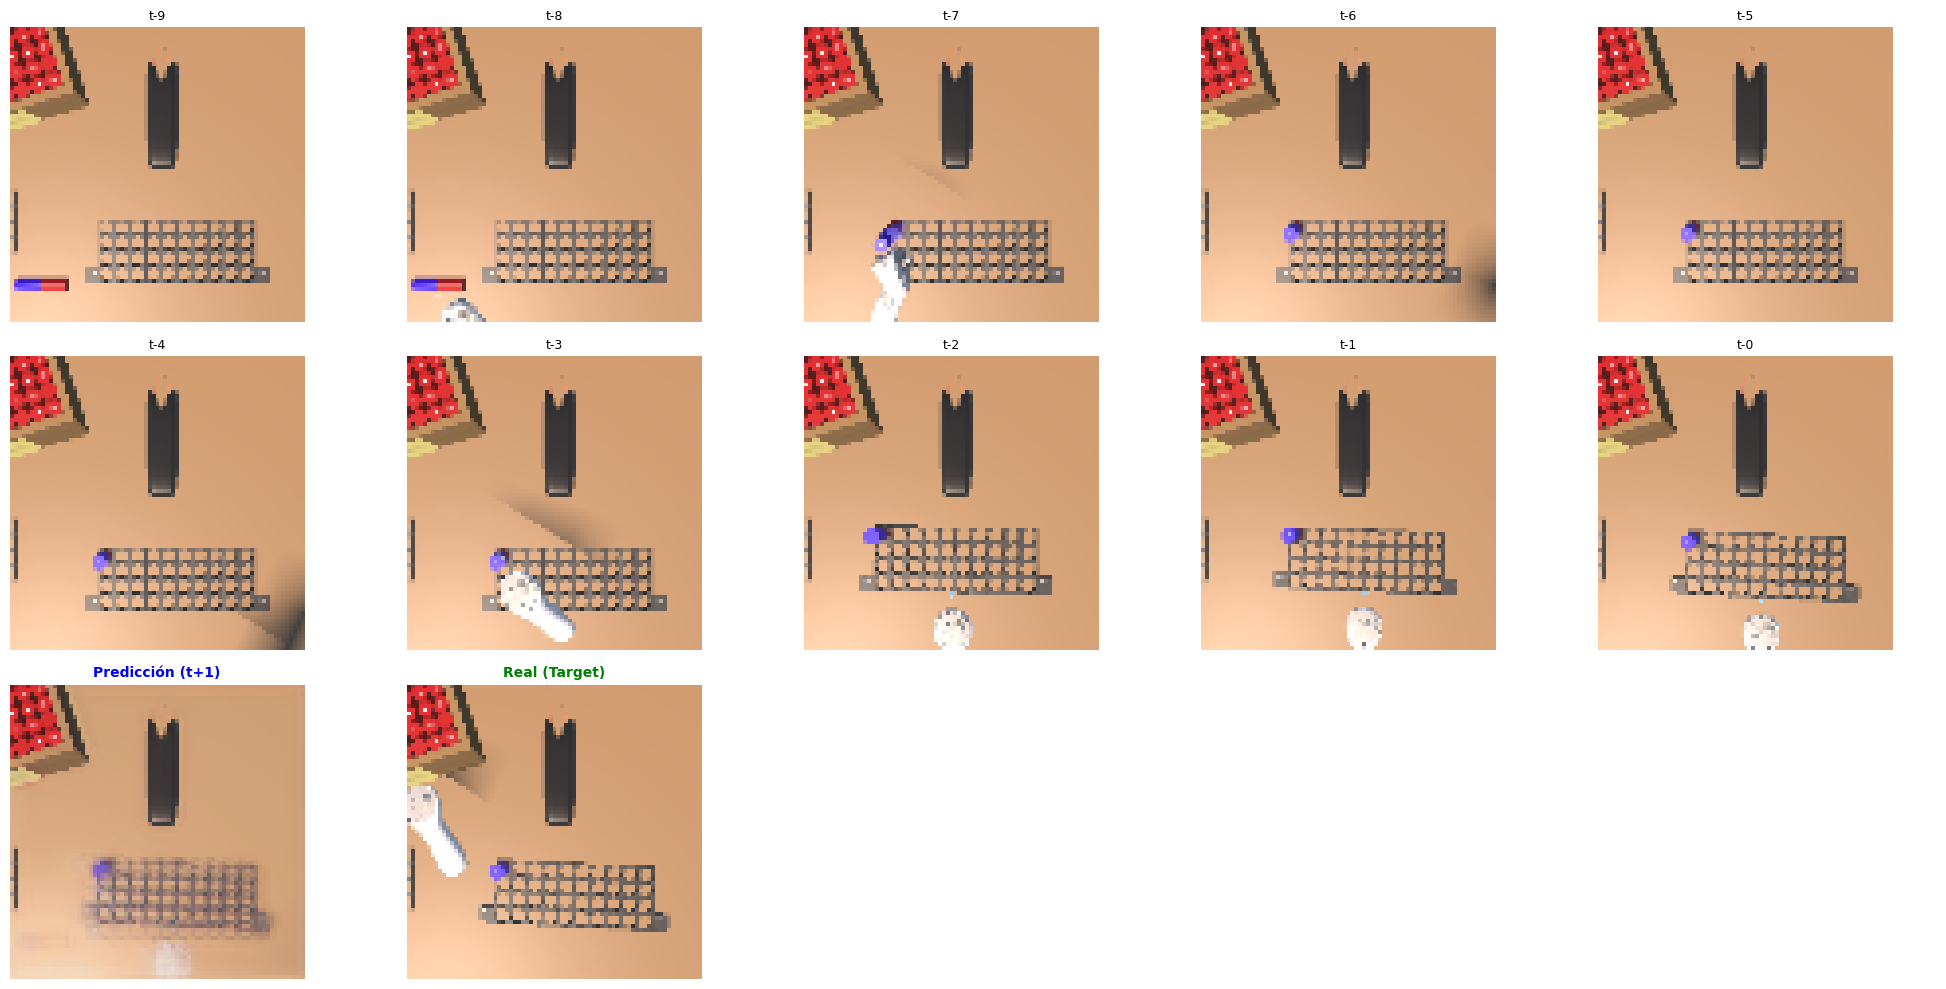

Prediciendo imagen 11 de session_001


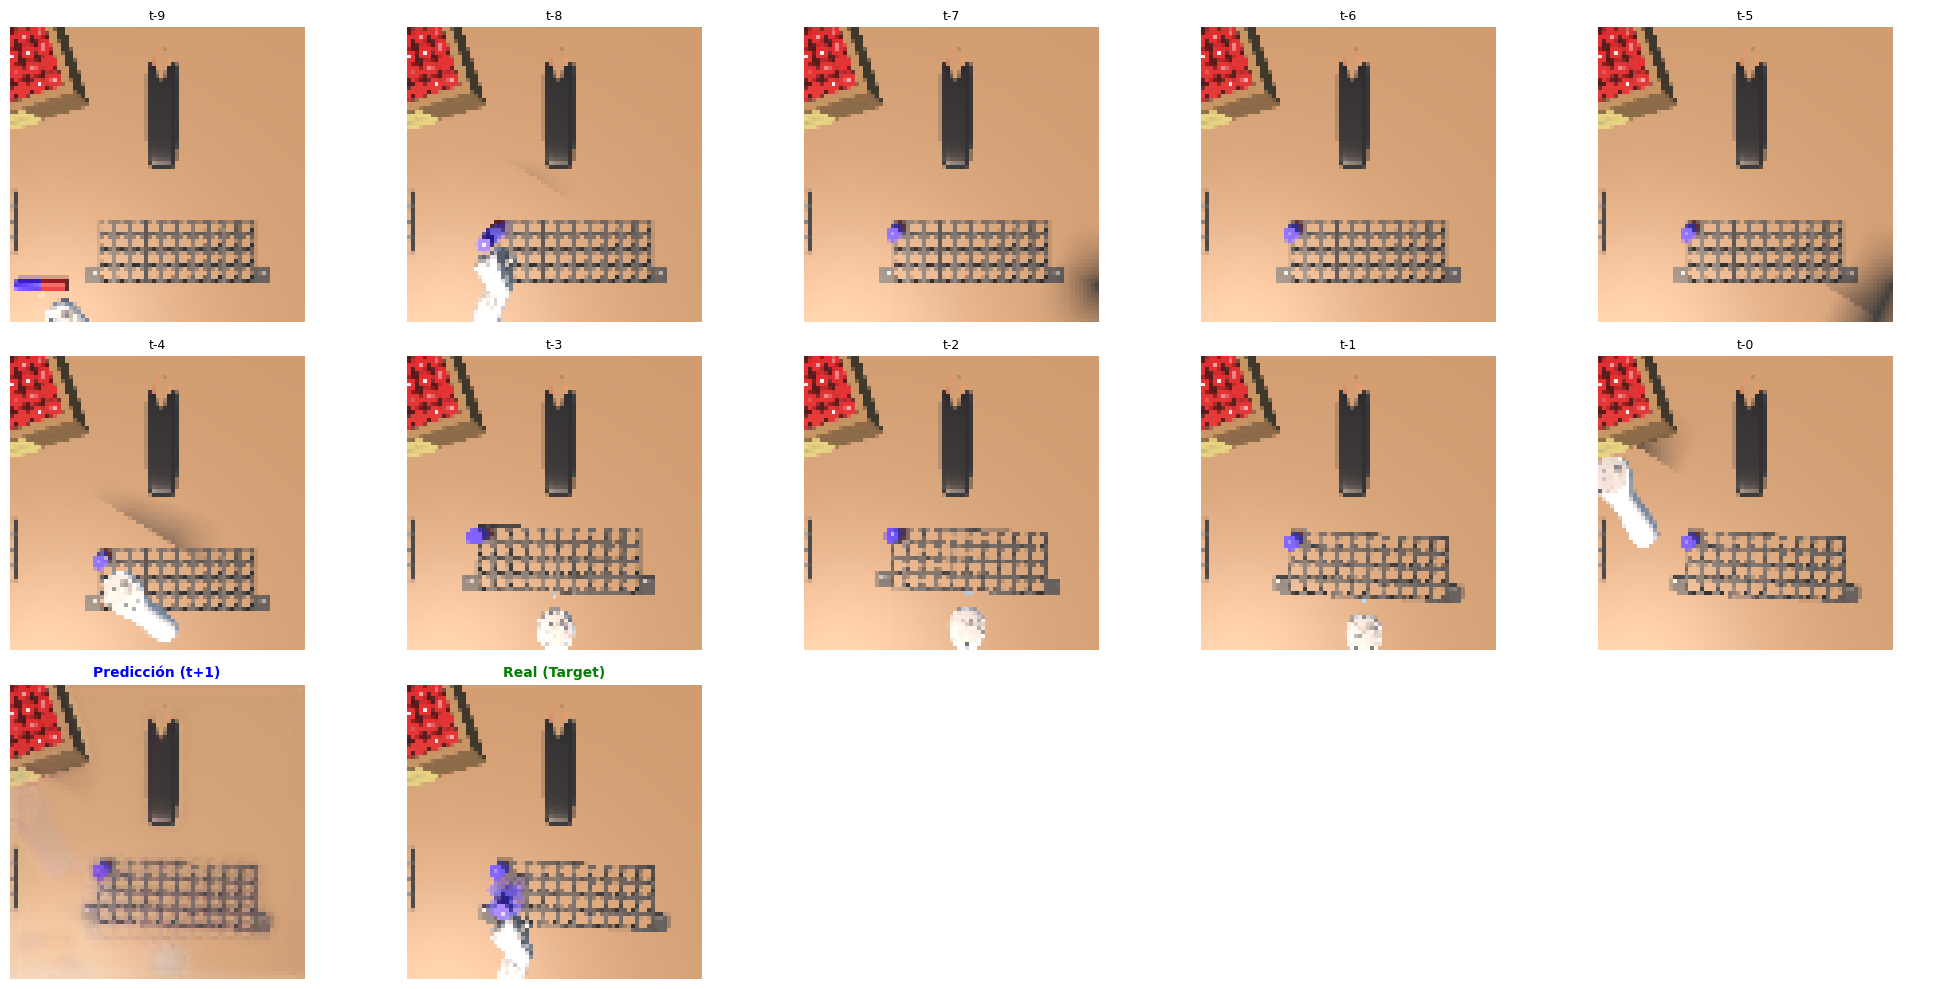

Prediciendo imagen 12 de session_001


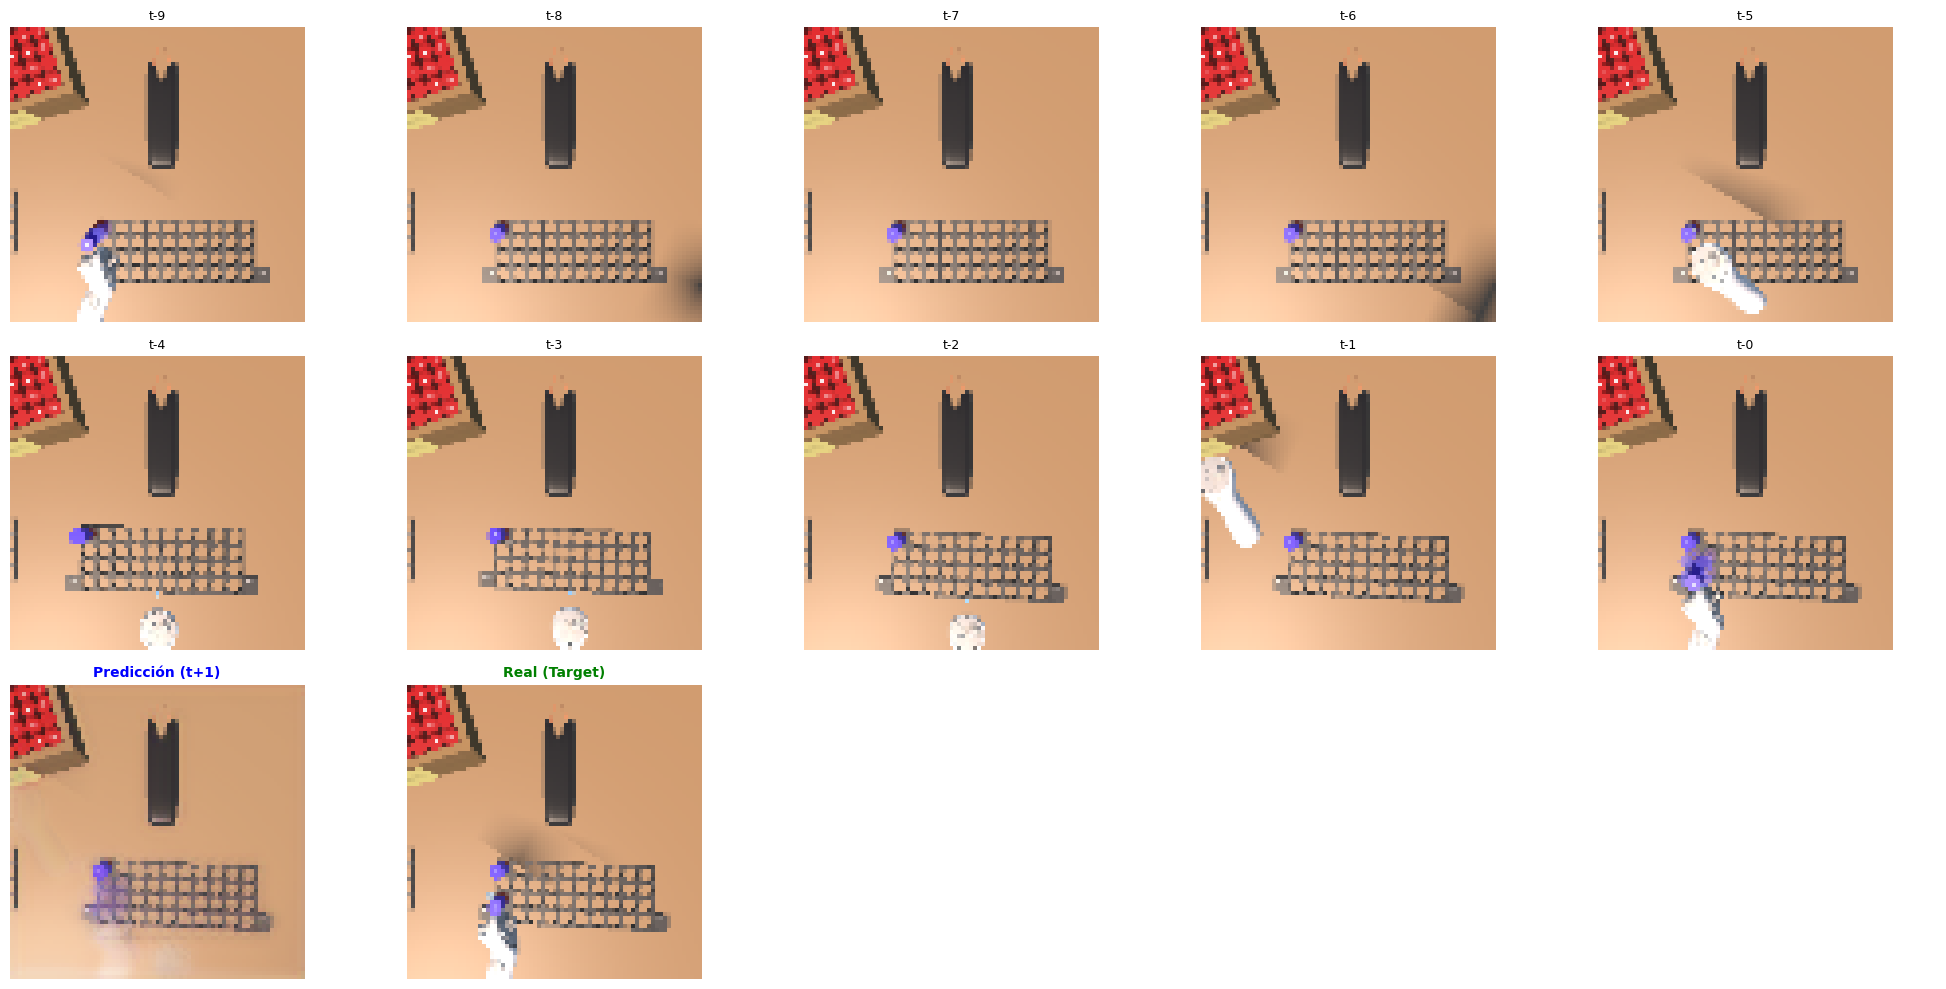

Prediciendo imagen 13 de session_001


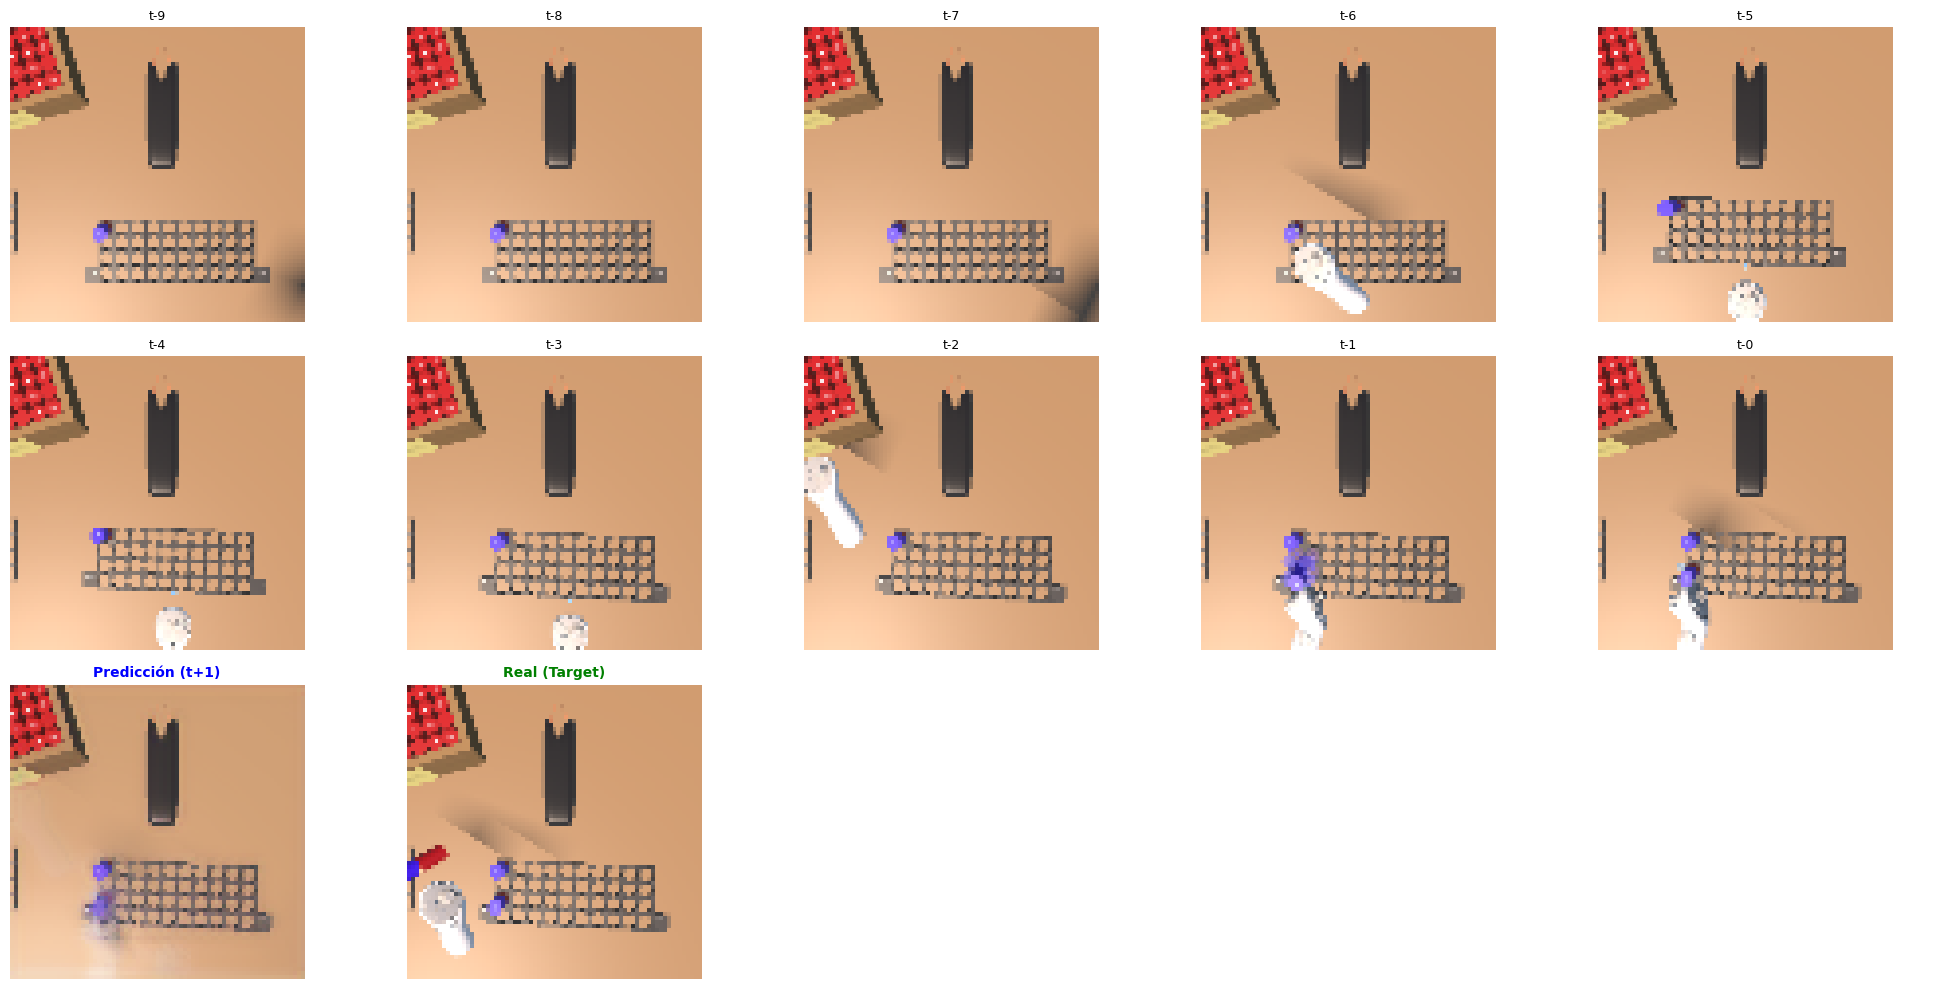

Prediciendo imagen 14 de session_001


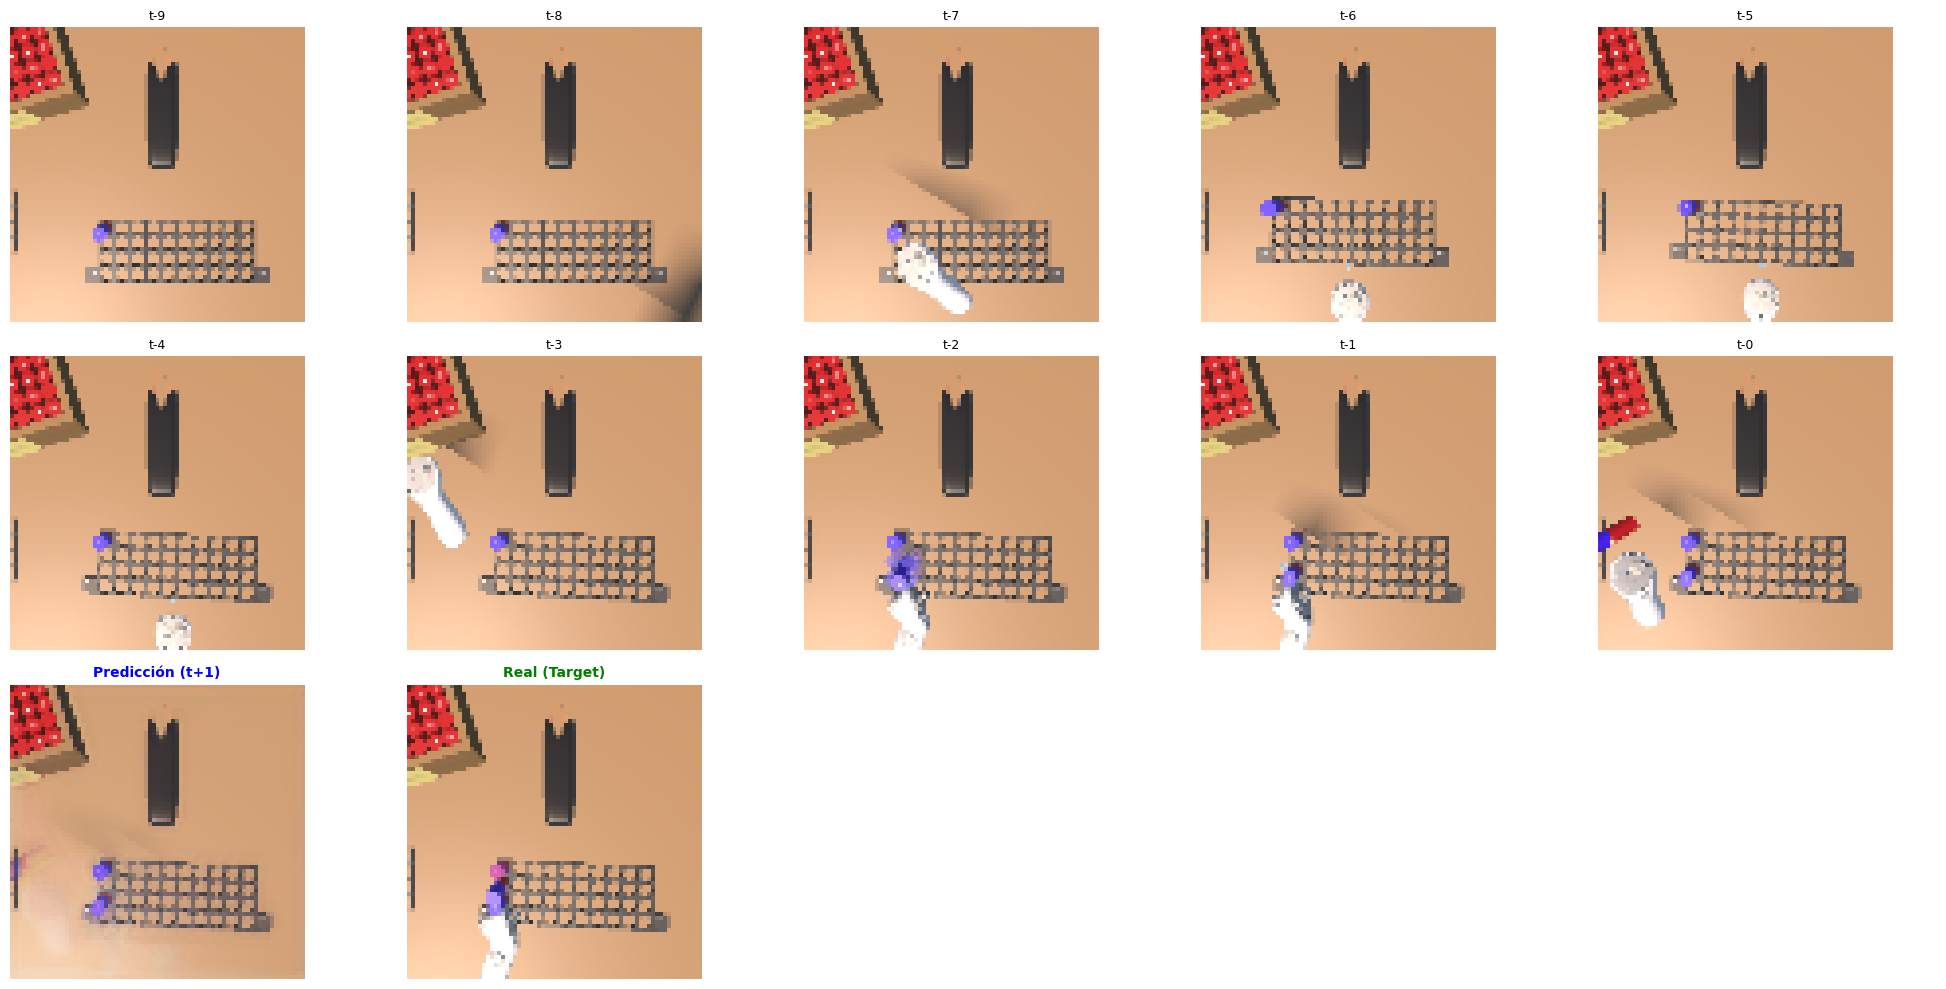

Prediciendo imagen 15 de session_001


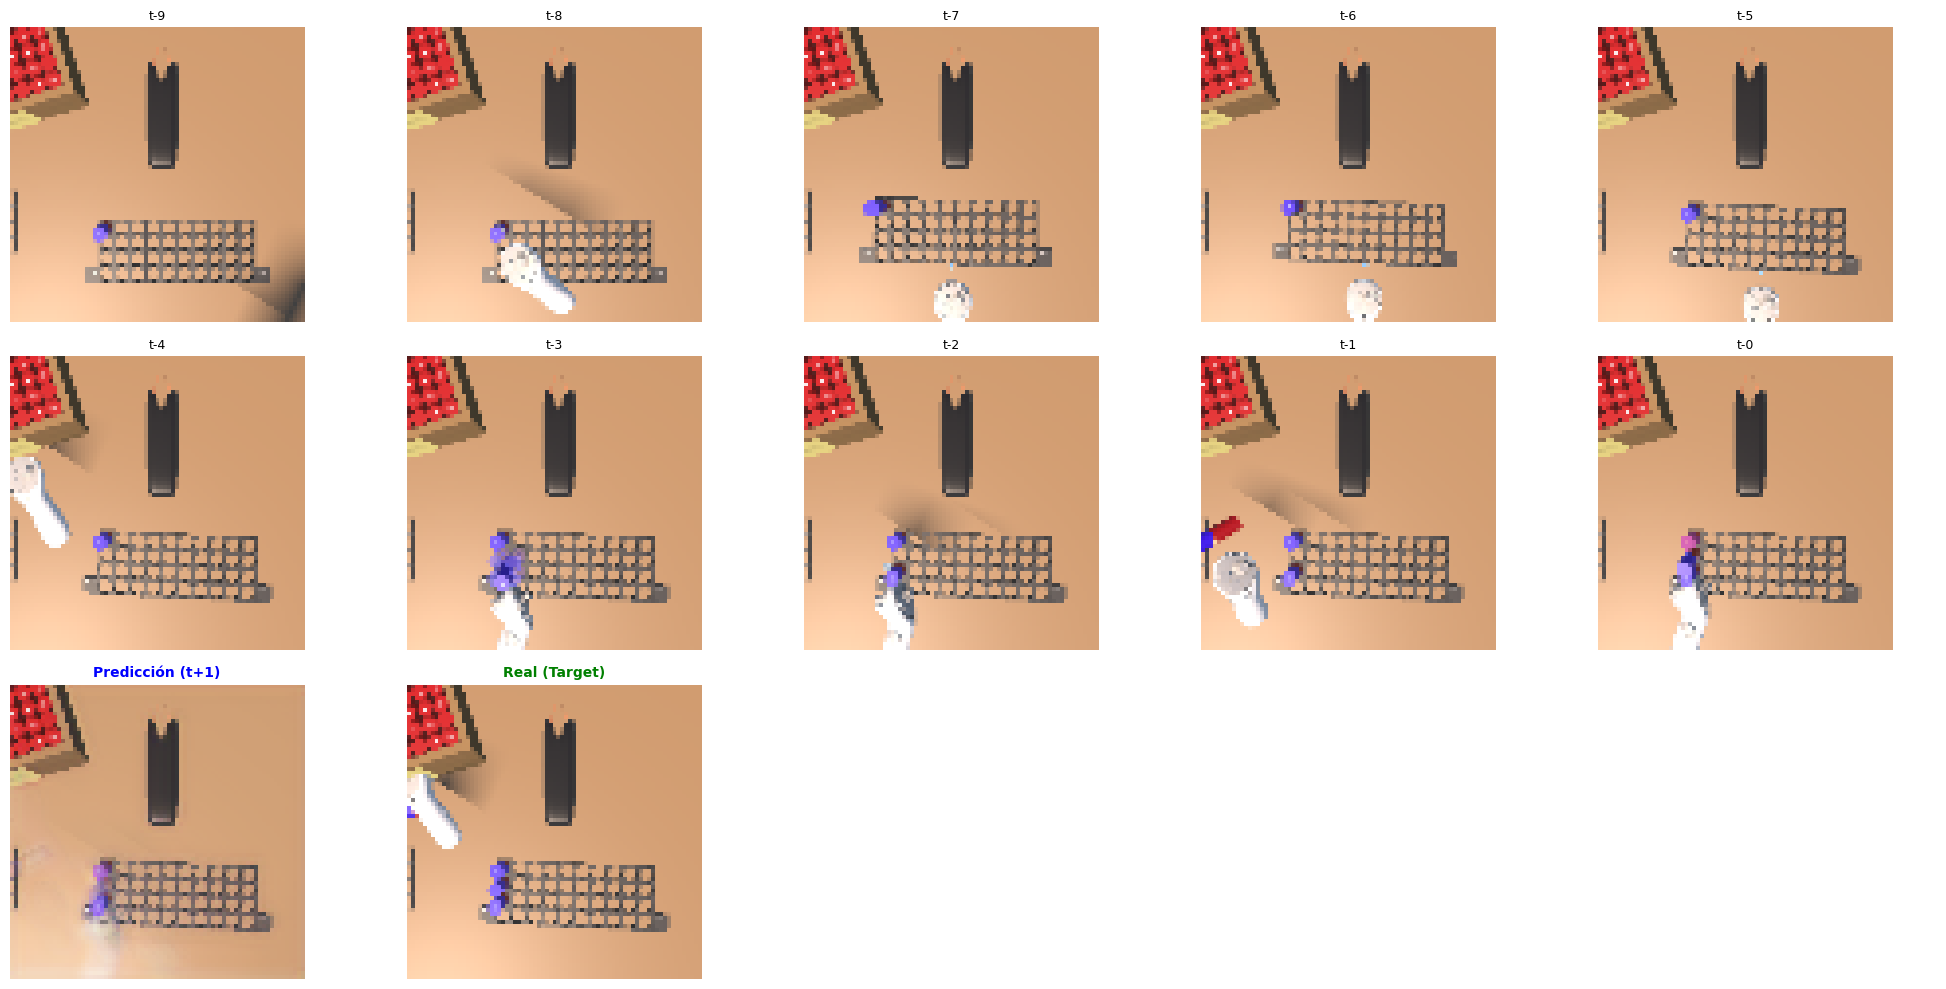

Prediciendo imagen 16 de session_001


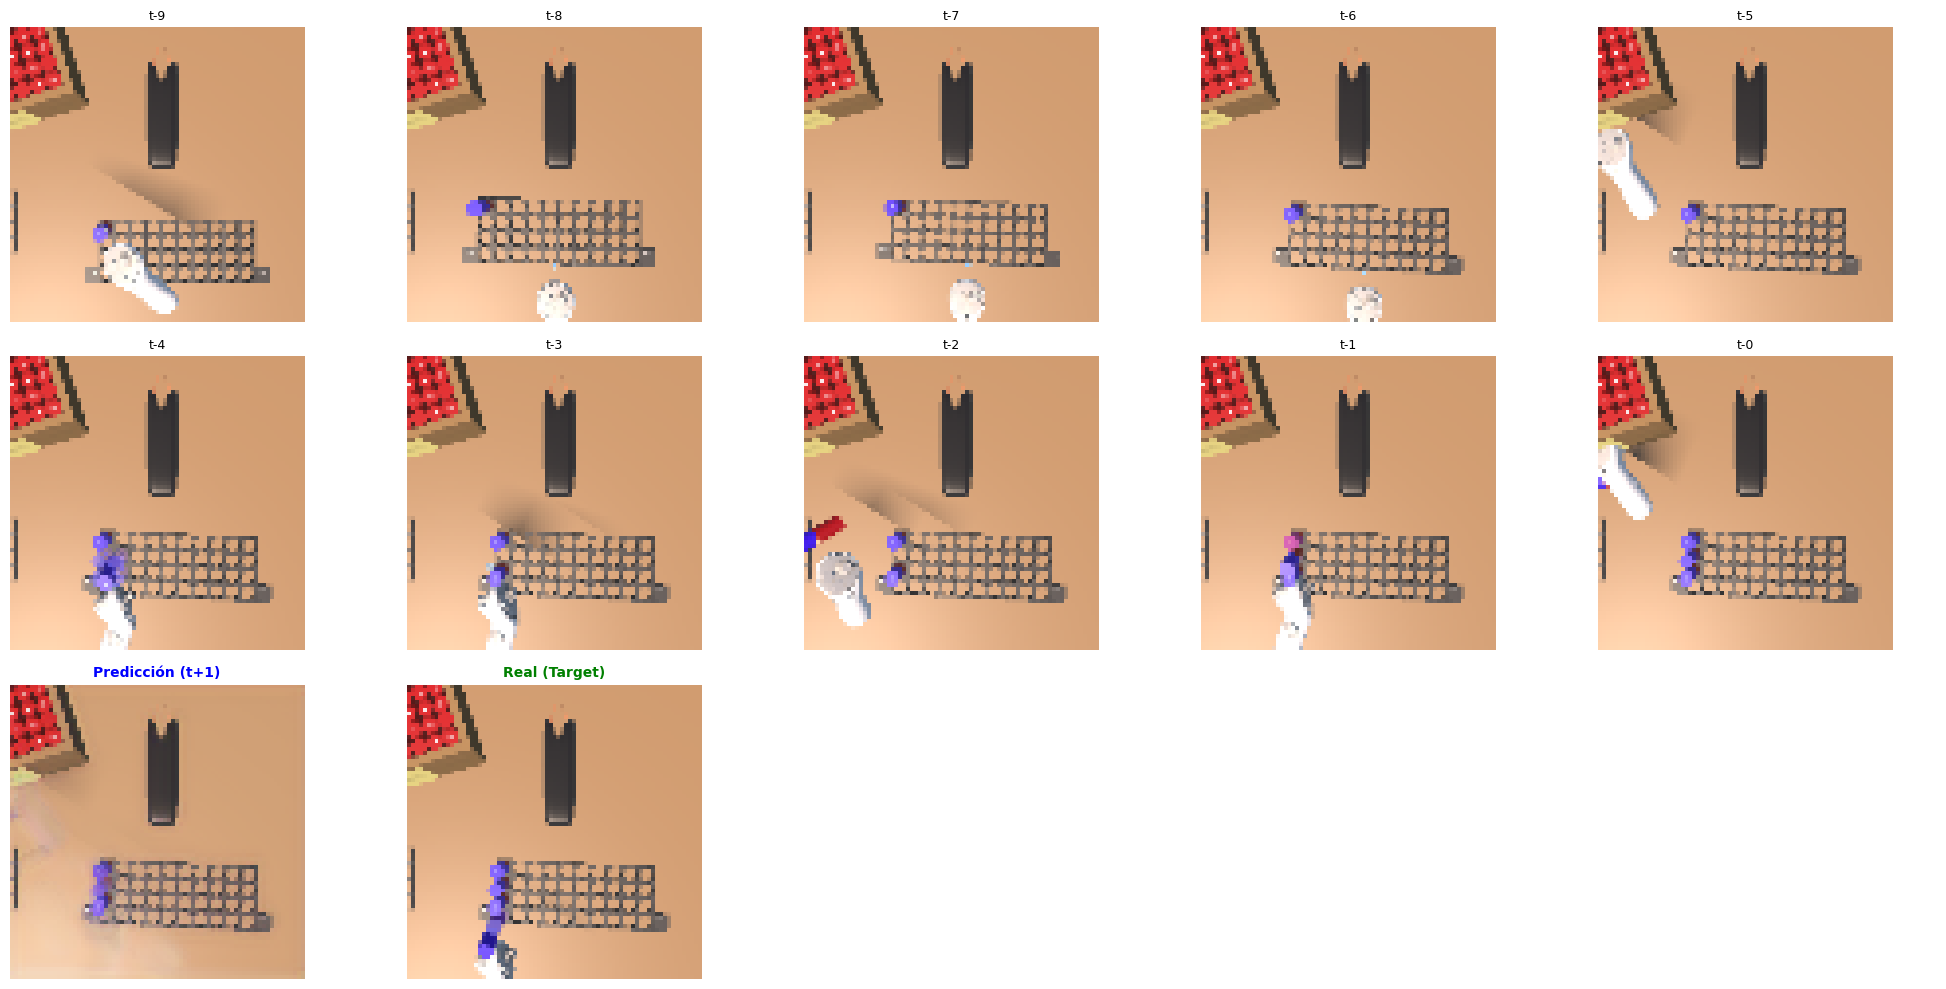

Prediciendo imagen 17 de session_001


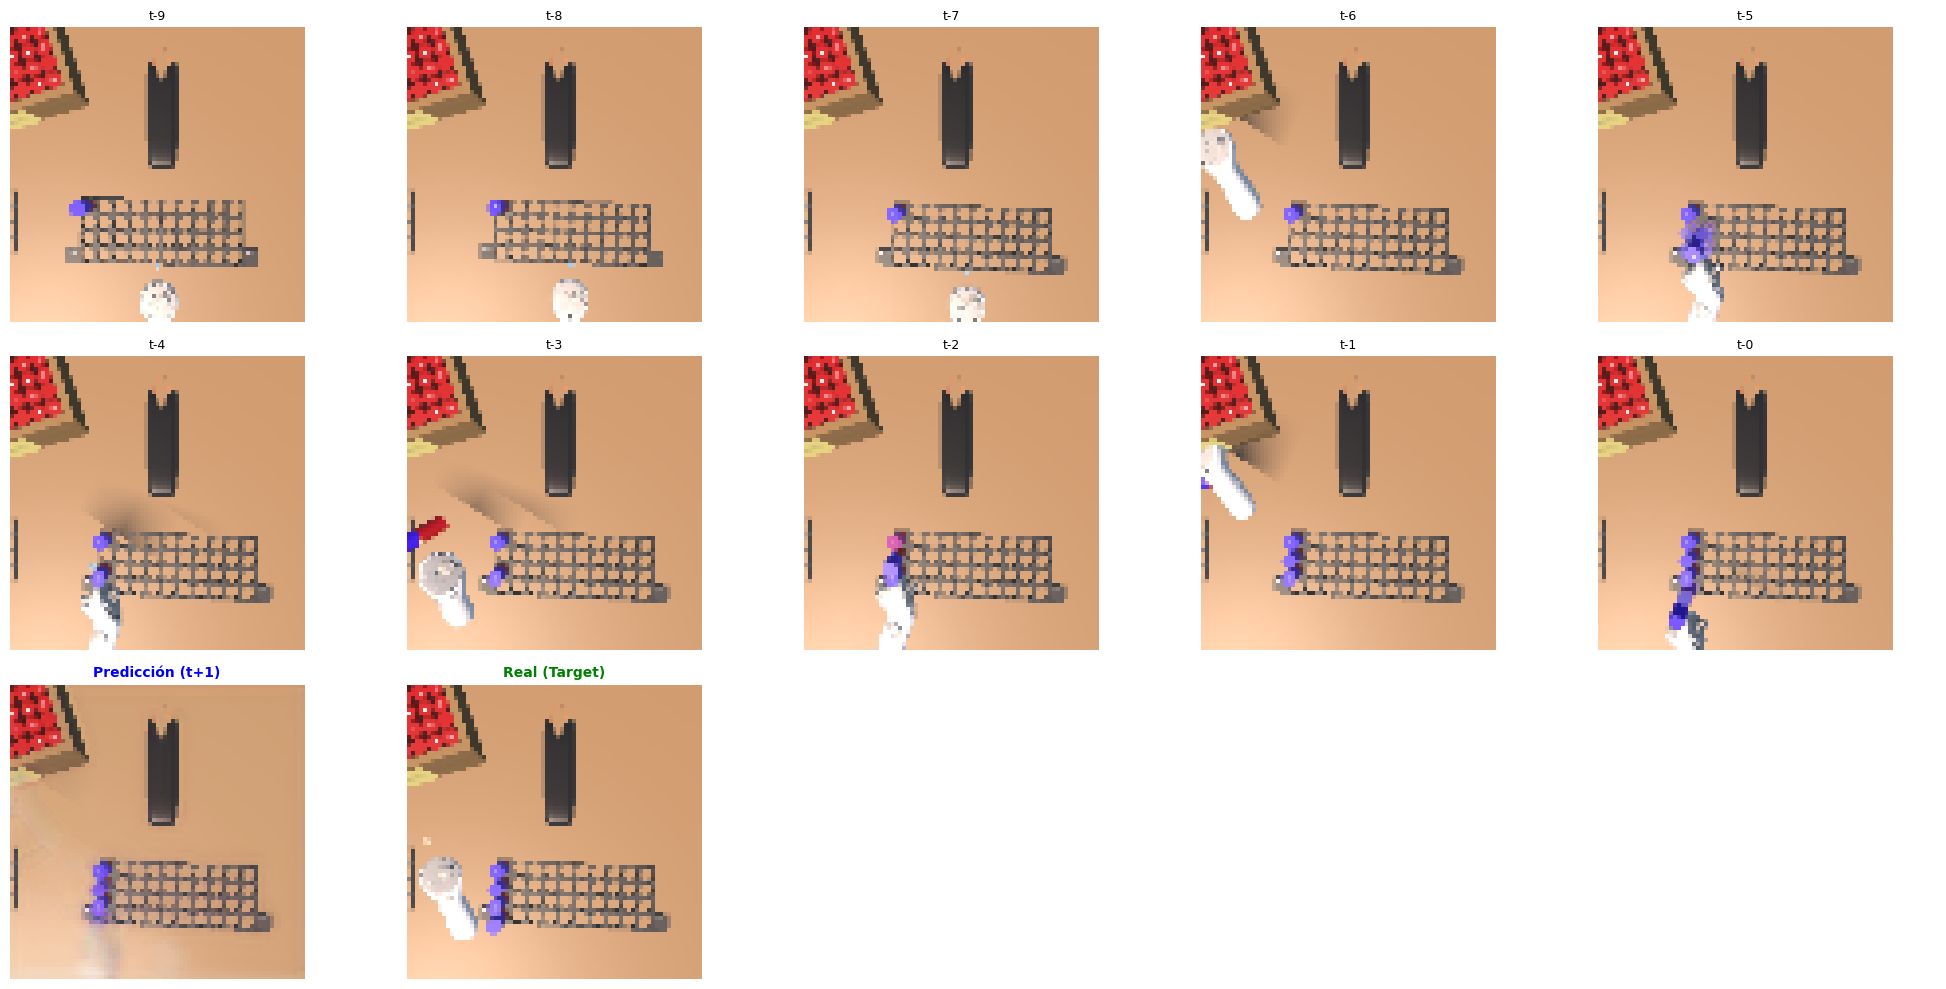

Prediciendo imagen 18 de session_001


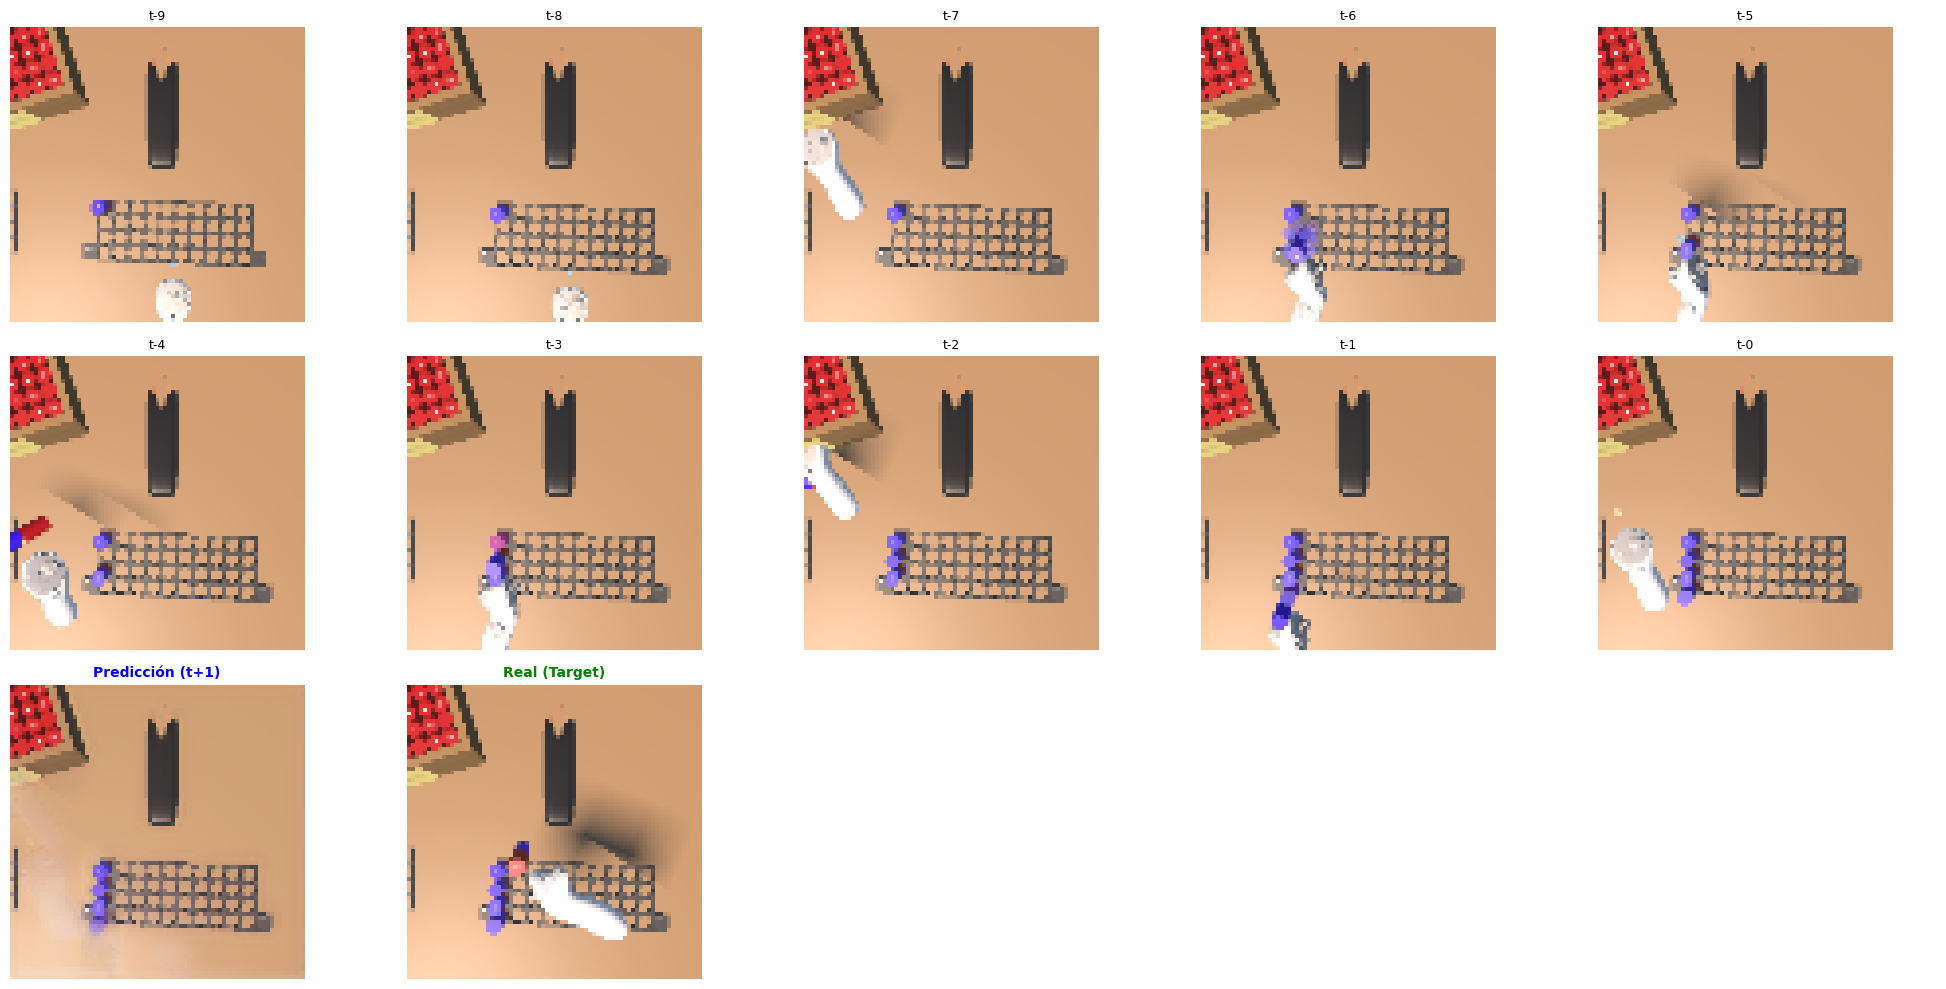

Prediciendo imagen 19 de session_001


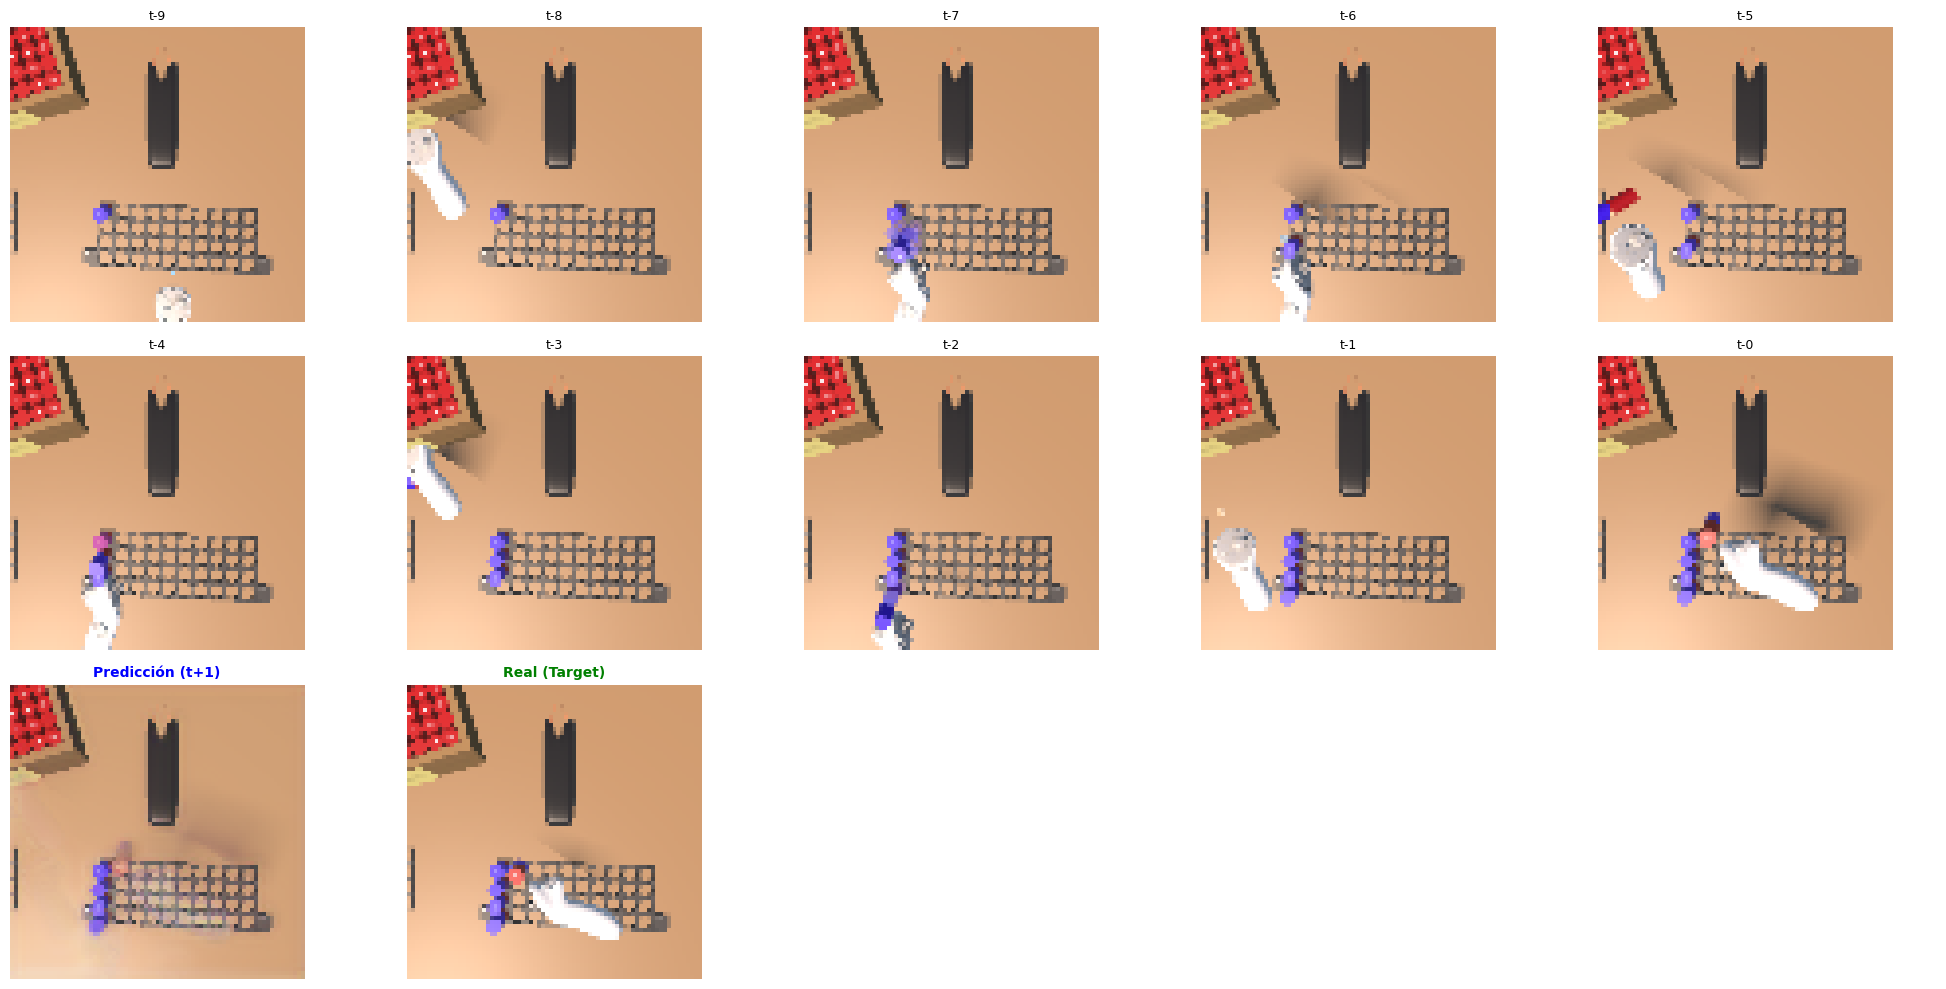

Prediciendo imagen 20 de session_001


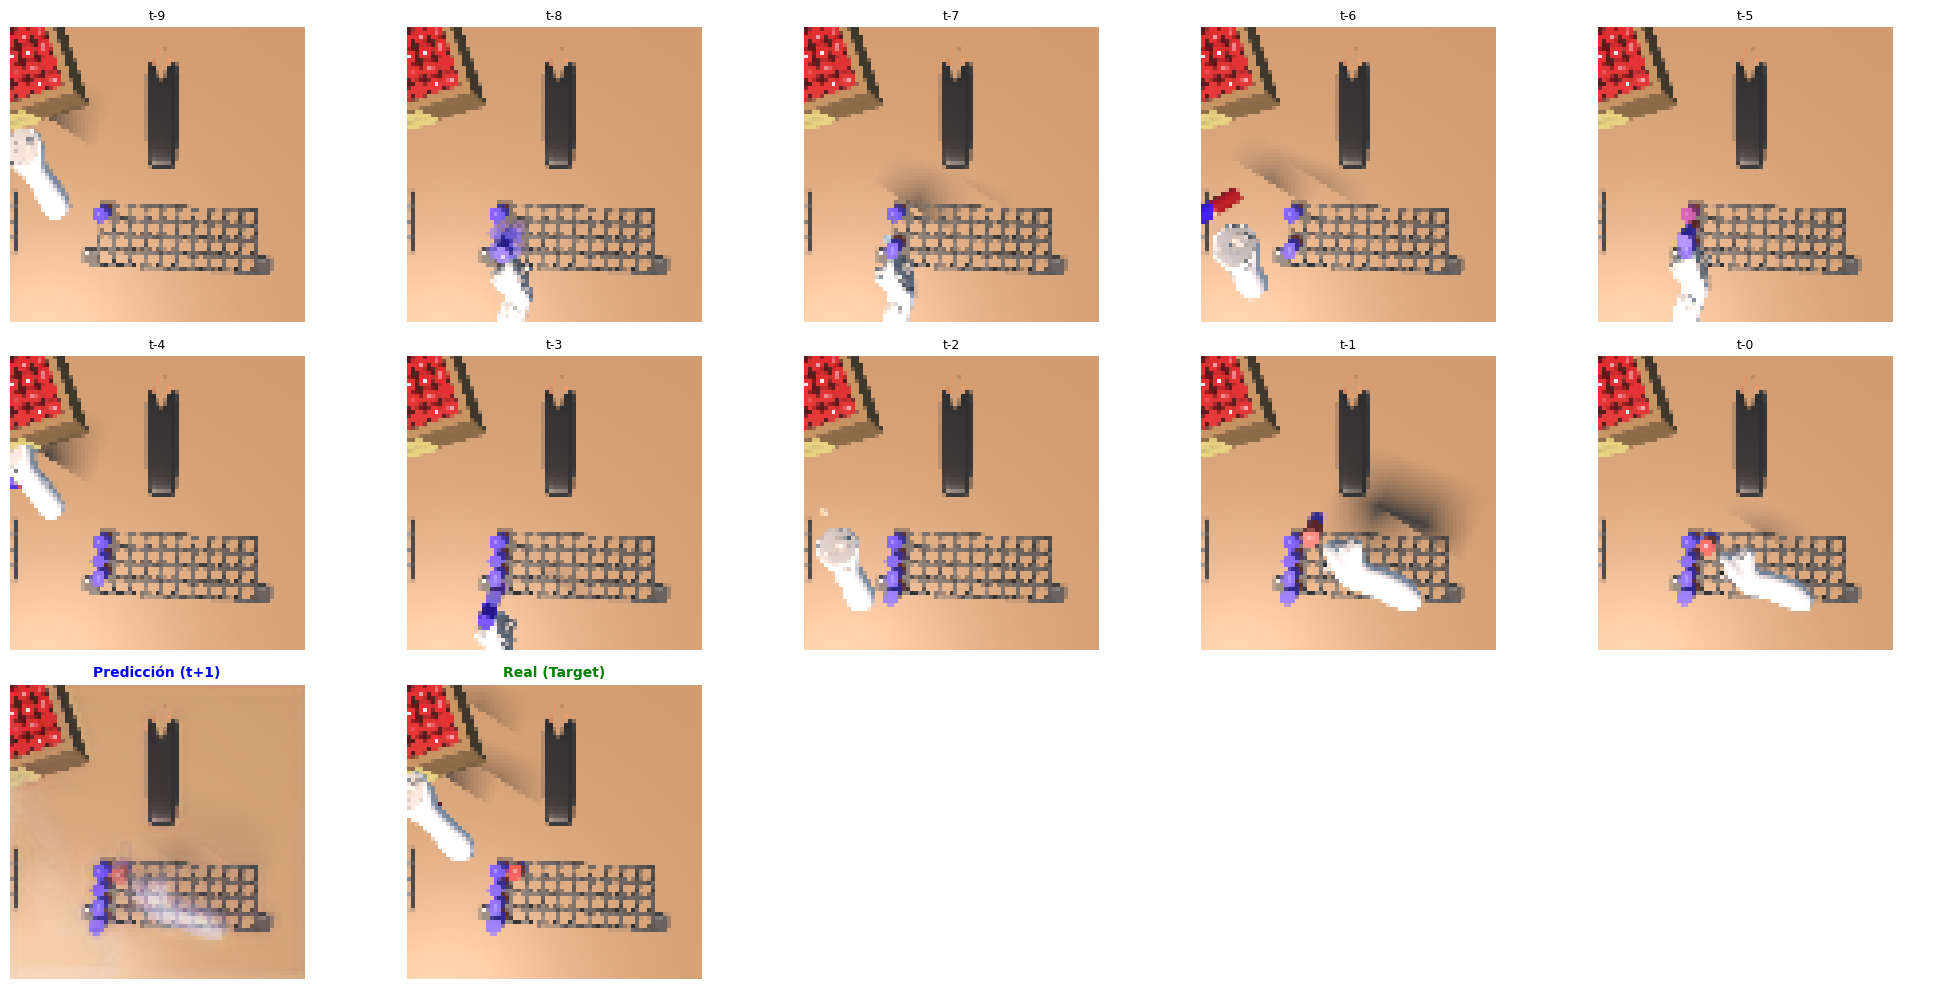

Prediciendo imagen 21 de session_001


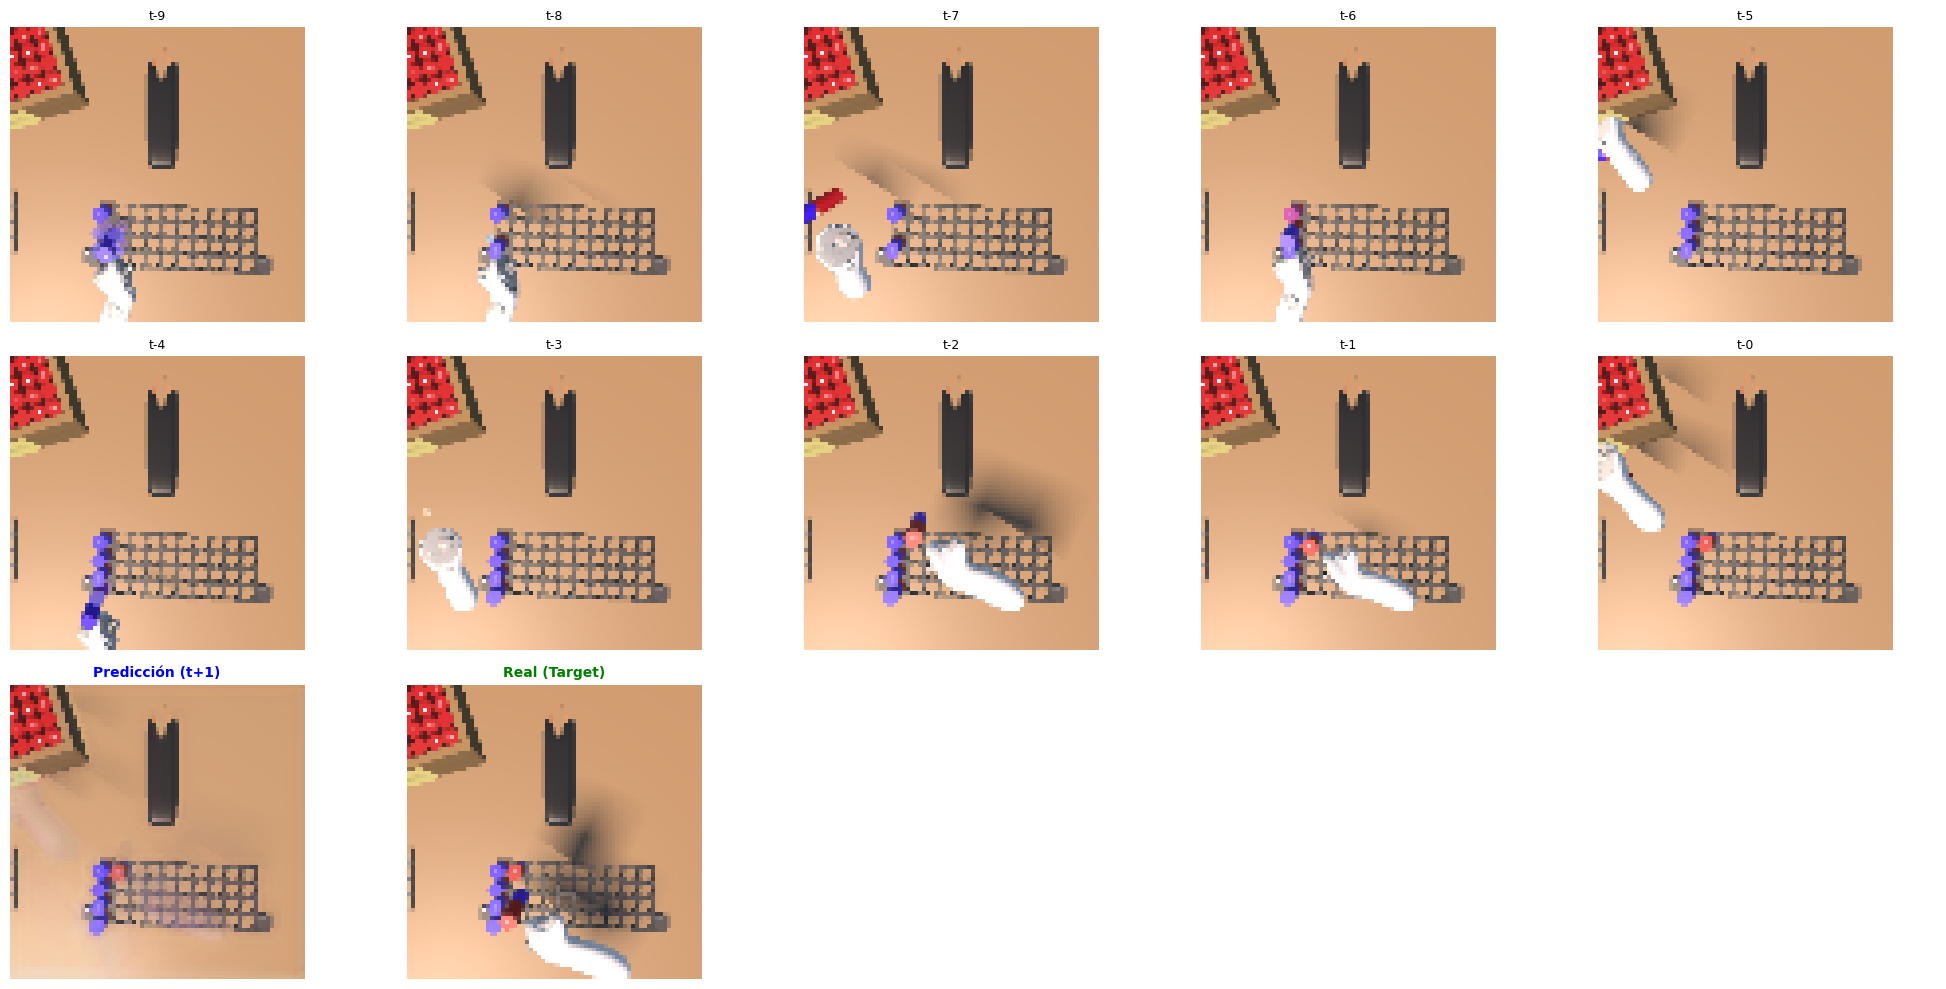

Prediciendo imagen 22 de session_001


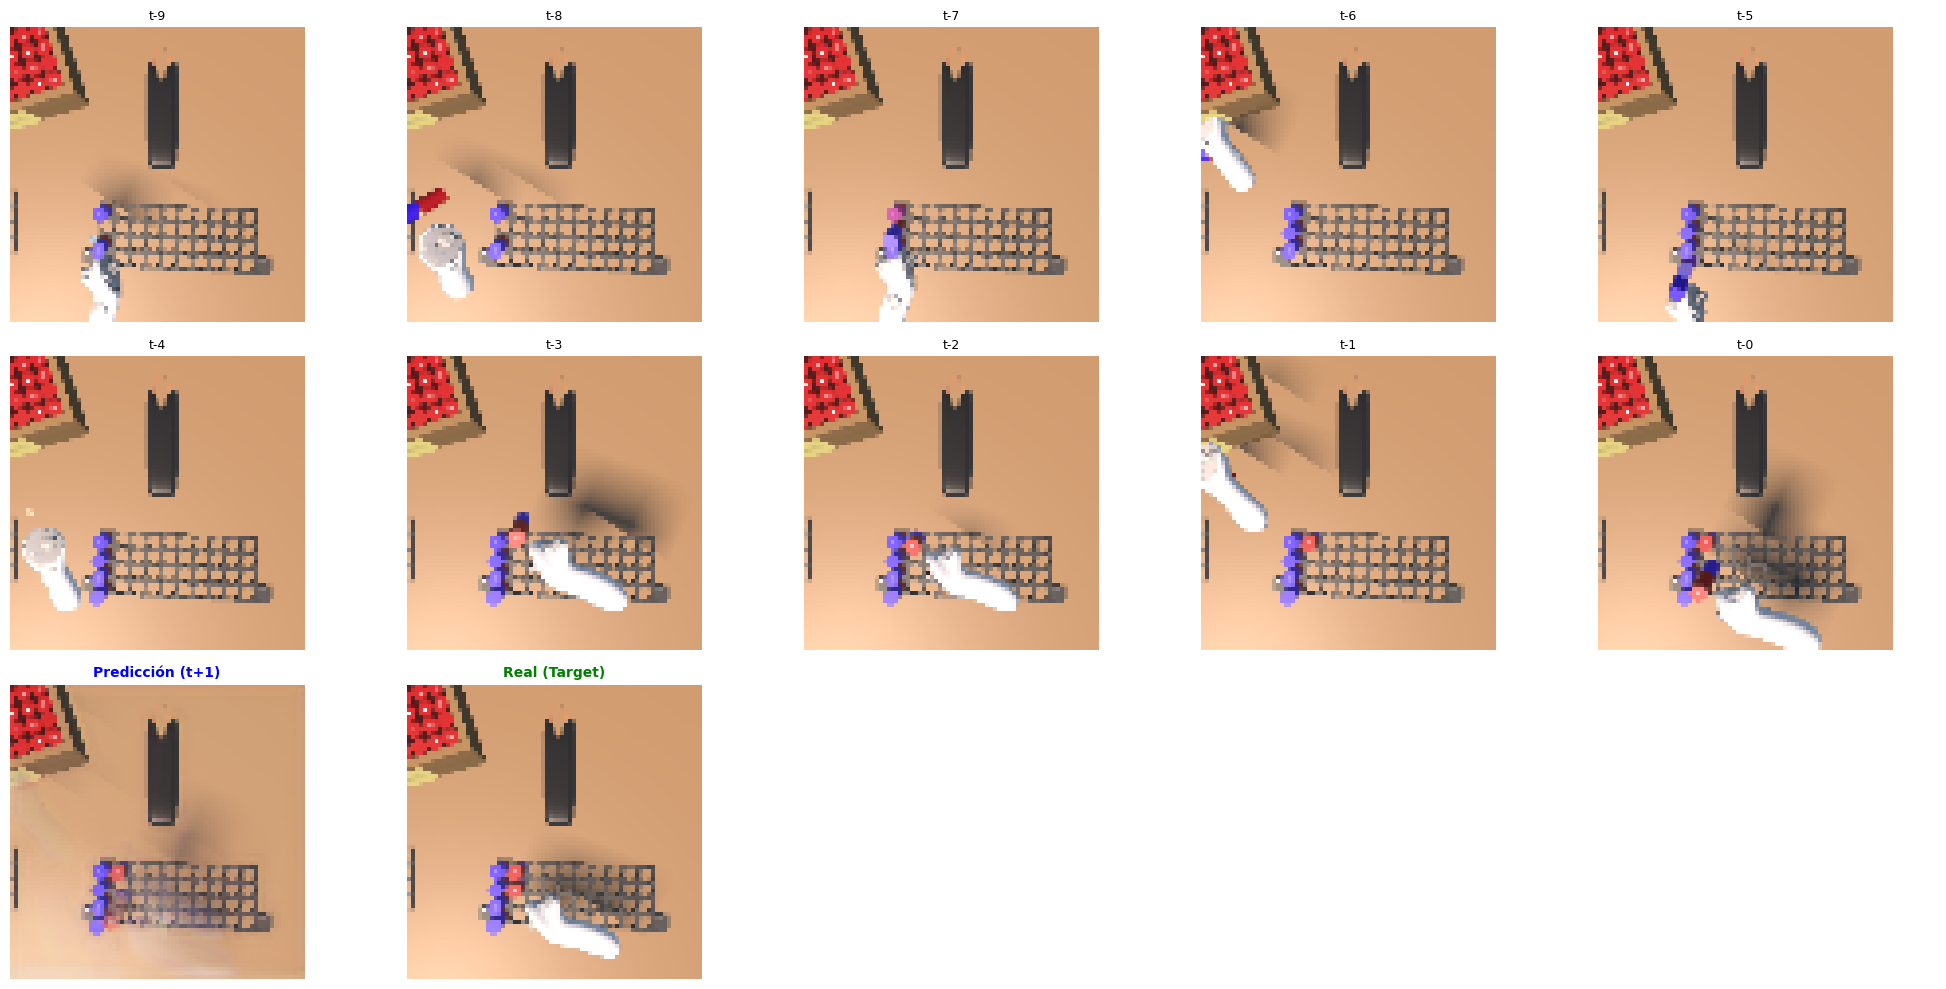

Prediciendo imagen 23 de session_001


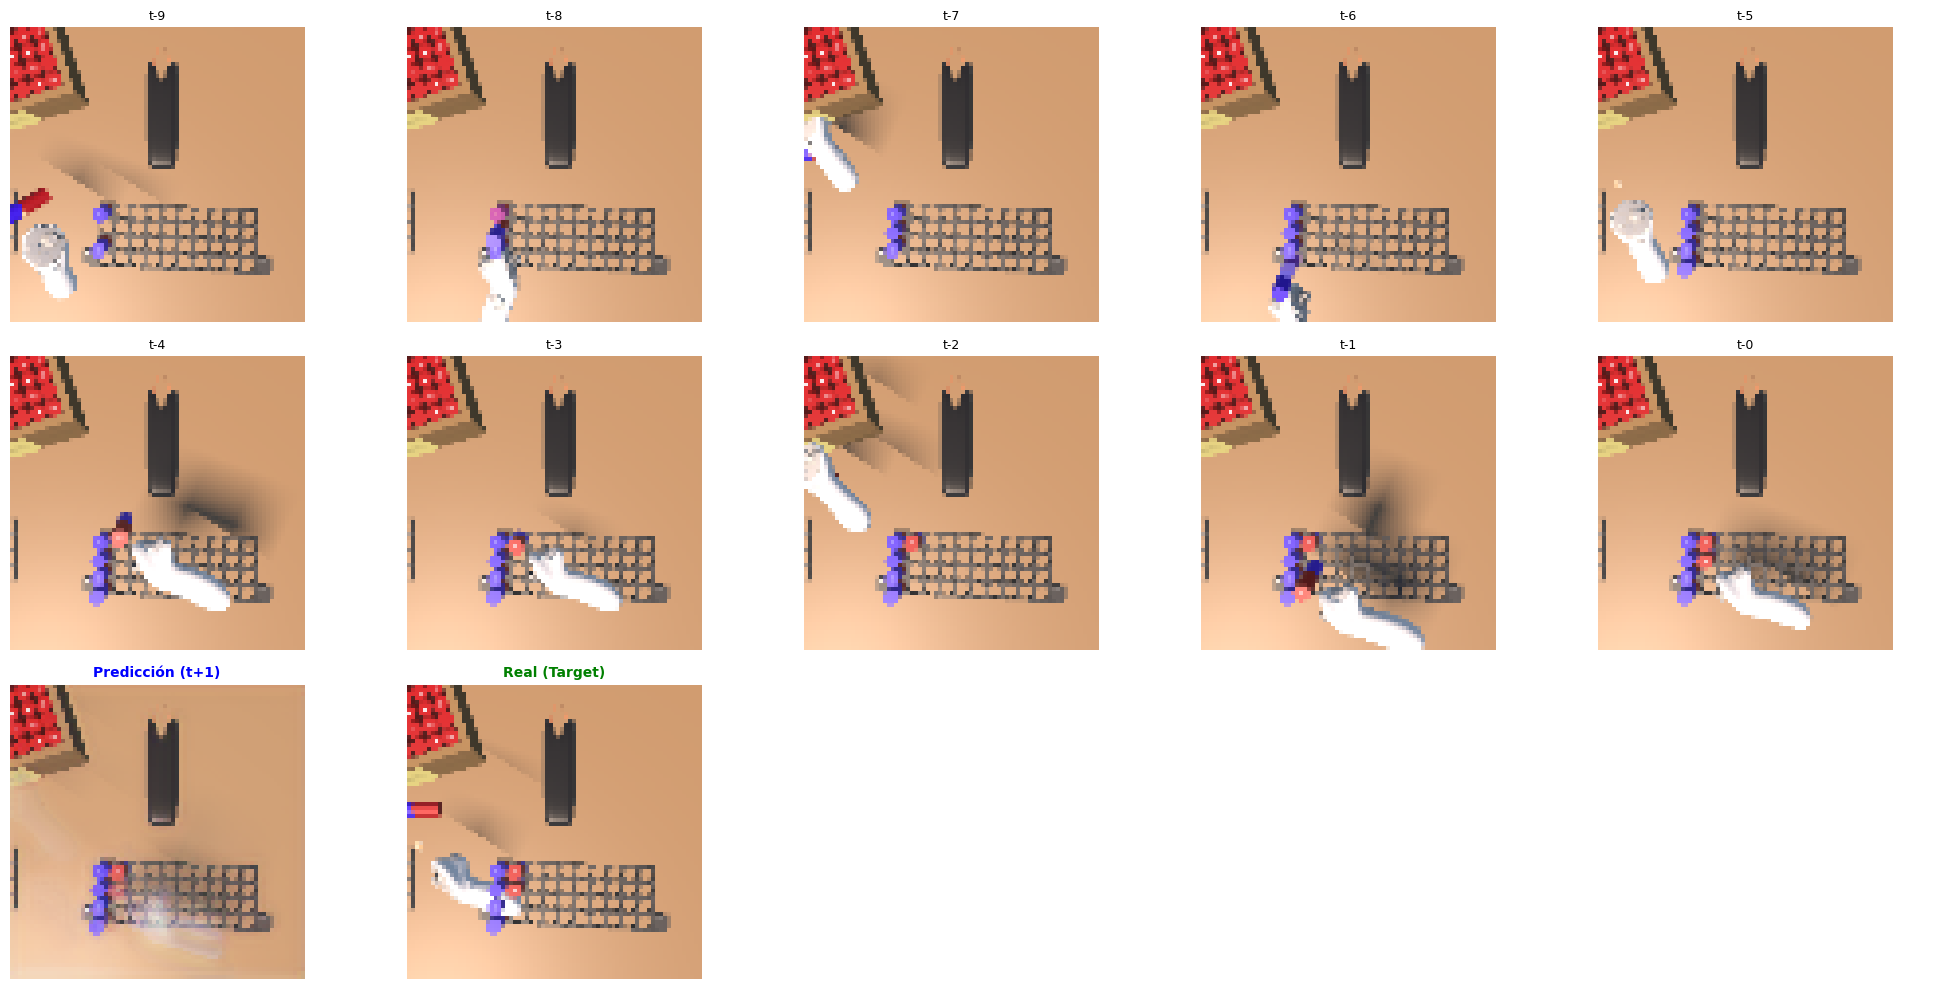

Prediciendo imagen 24 de session_001


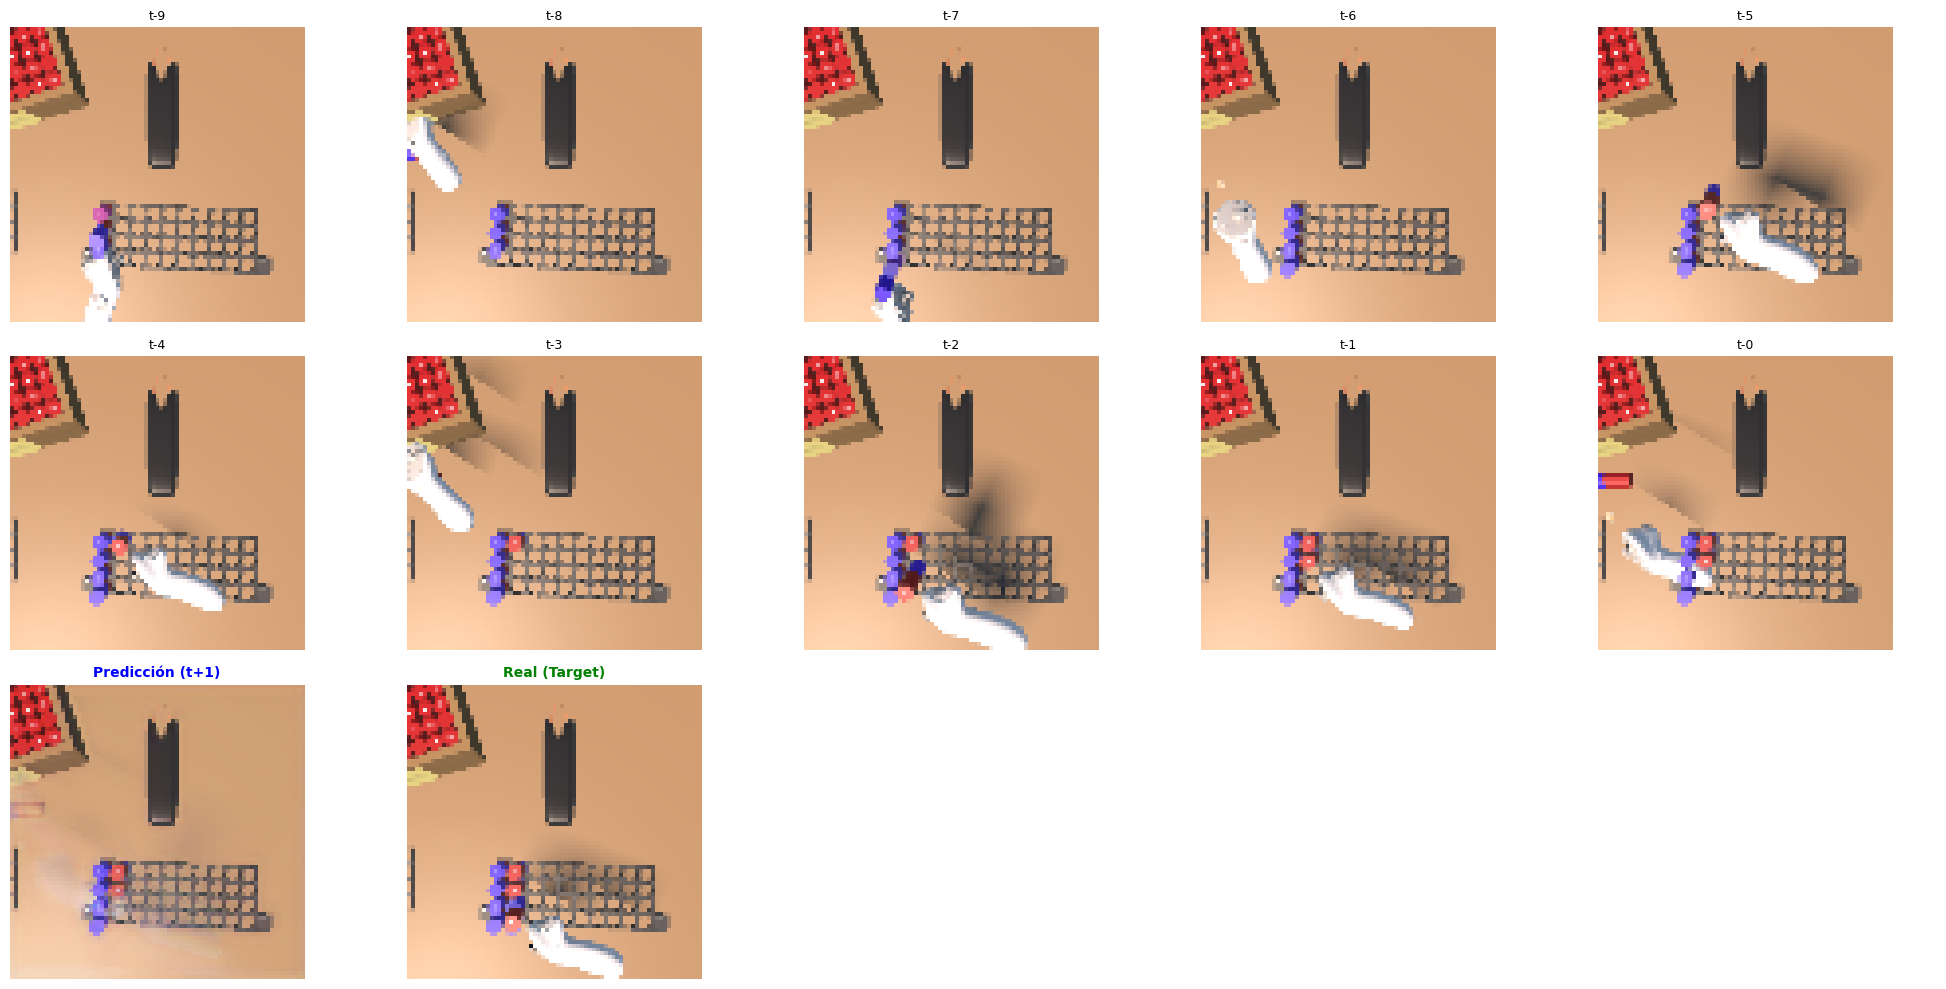

Prediciendo imagen 25 de session_001


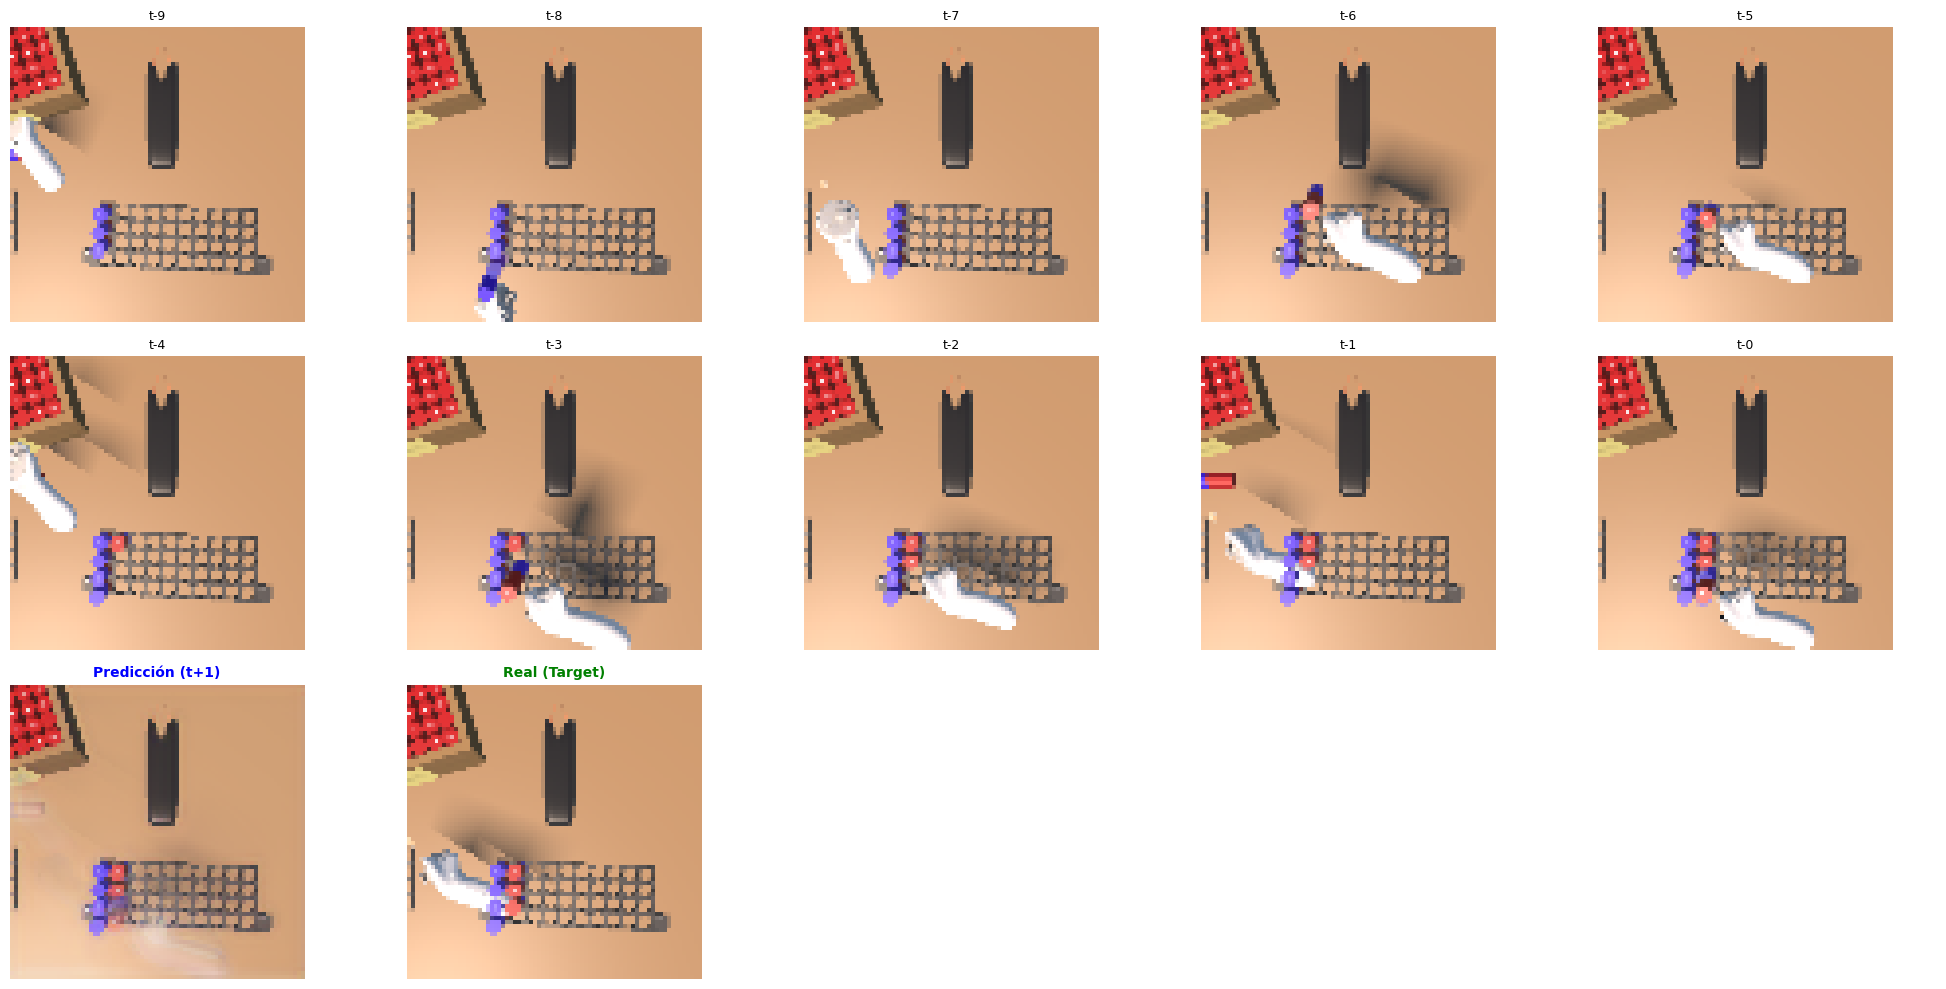

Prediciendo imagen 26 de session_001


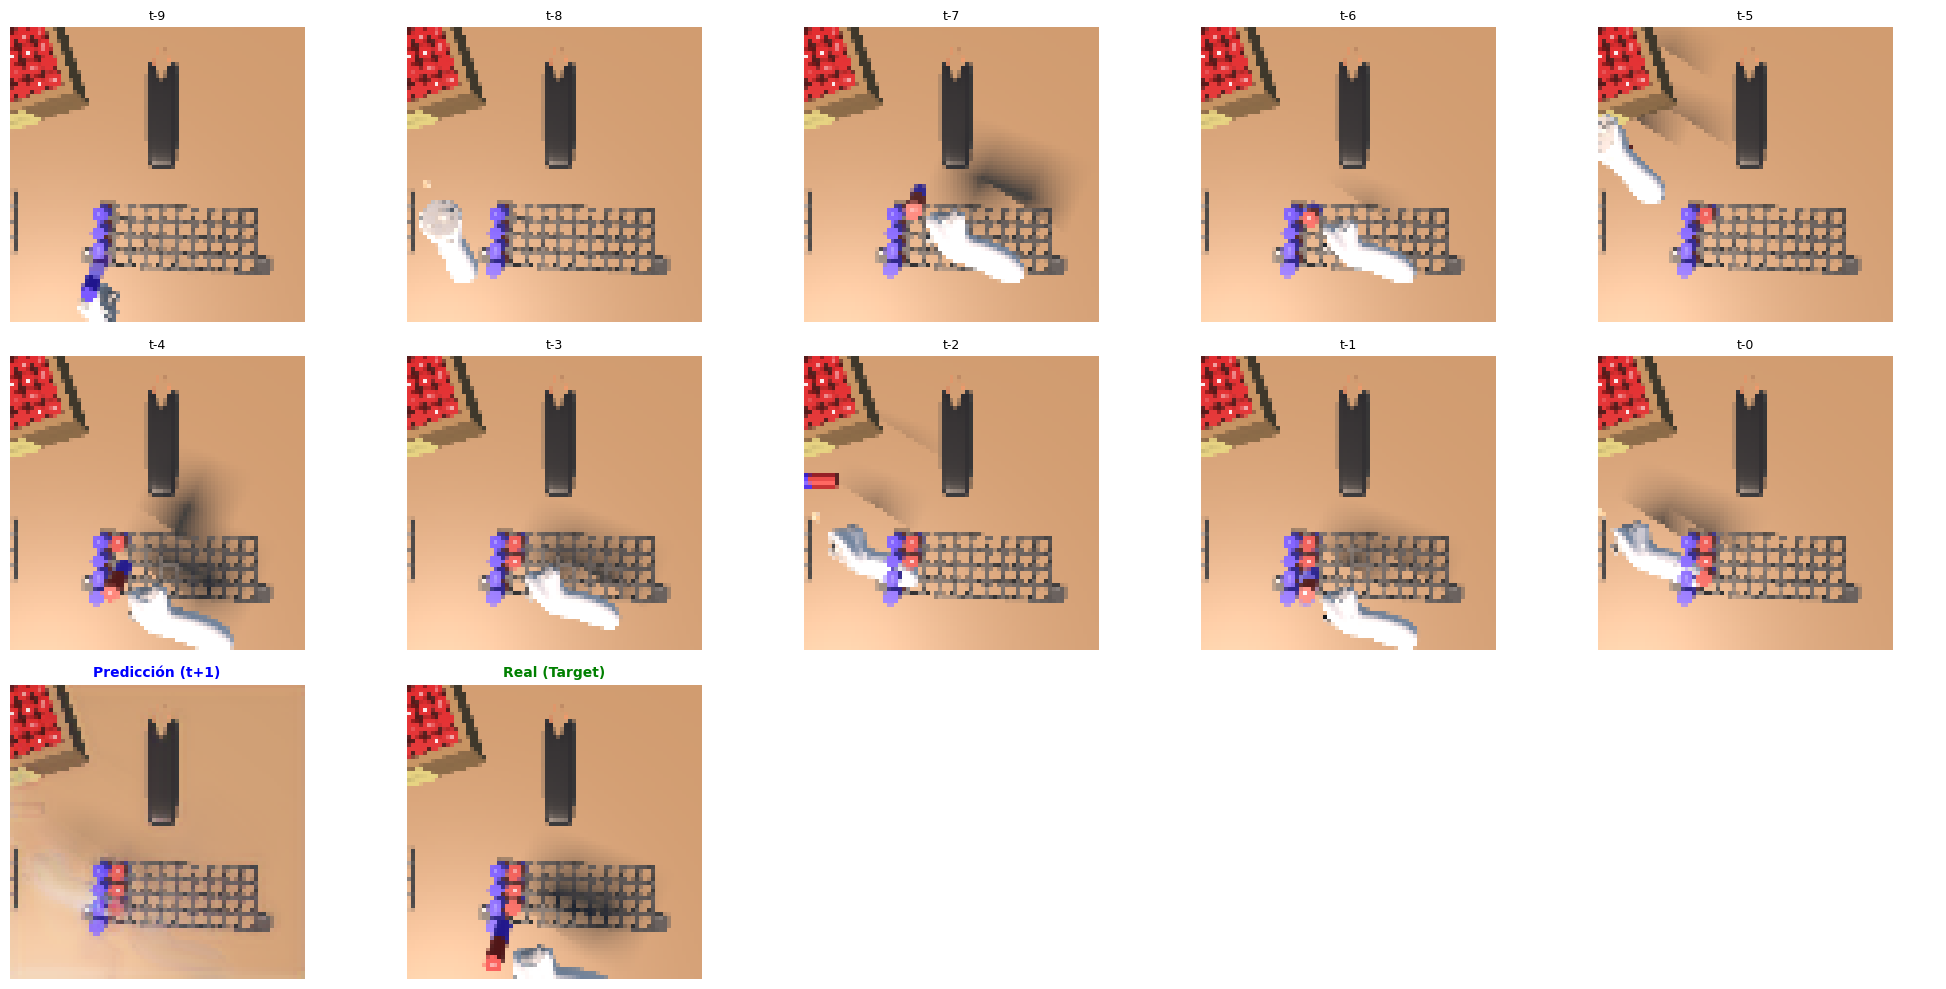

Prediciendo imagen 27 de session_001


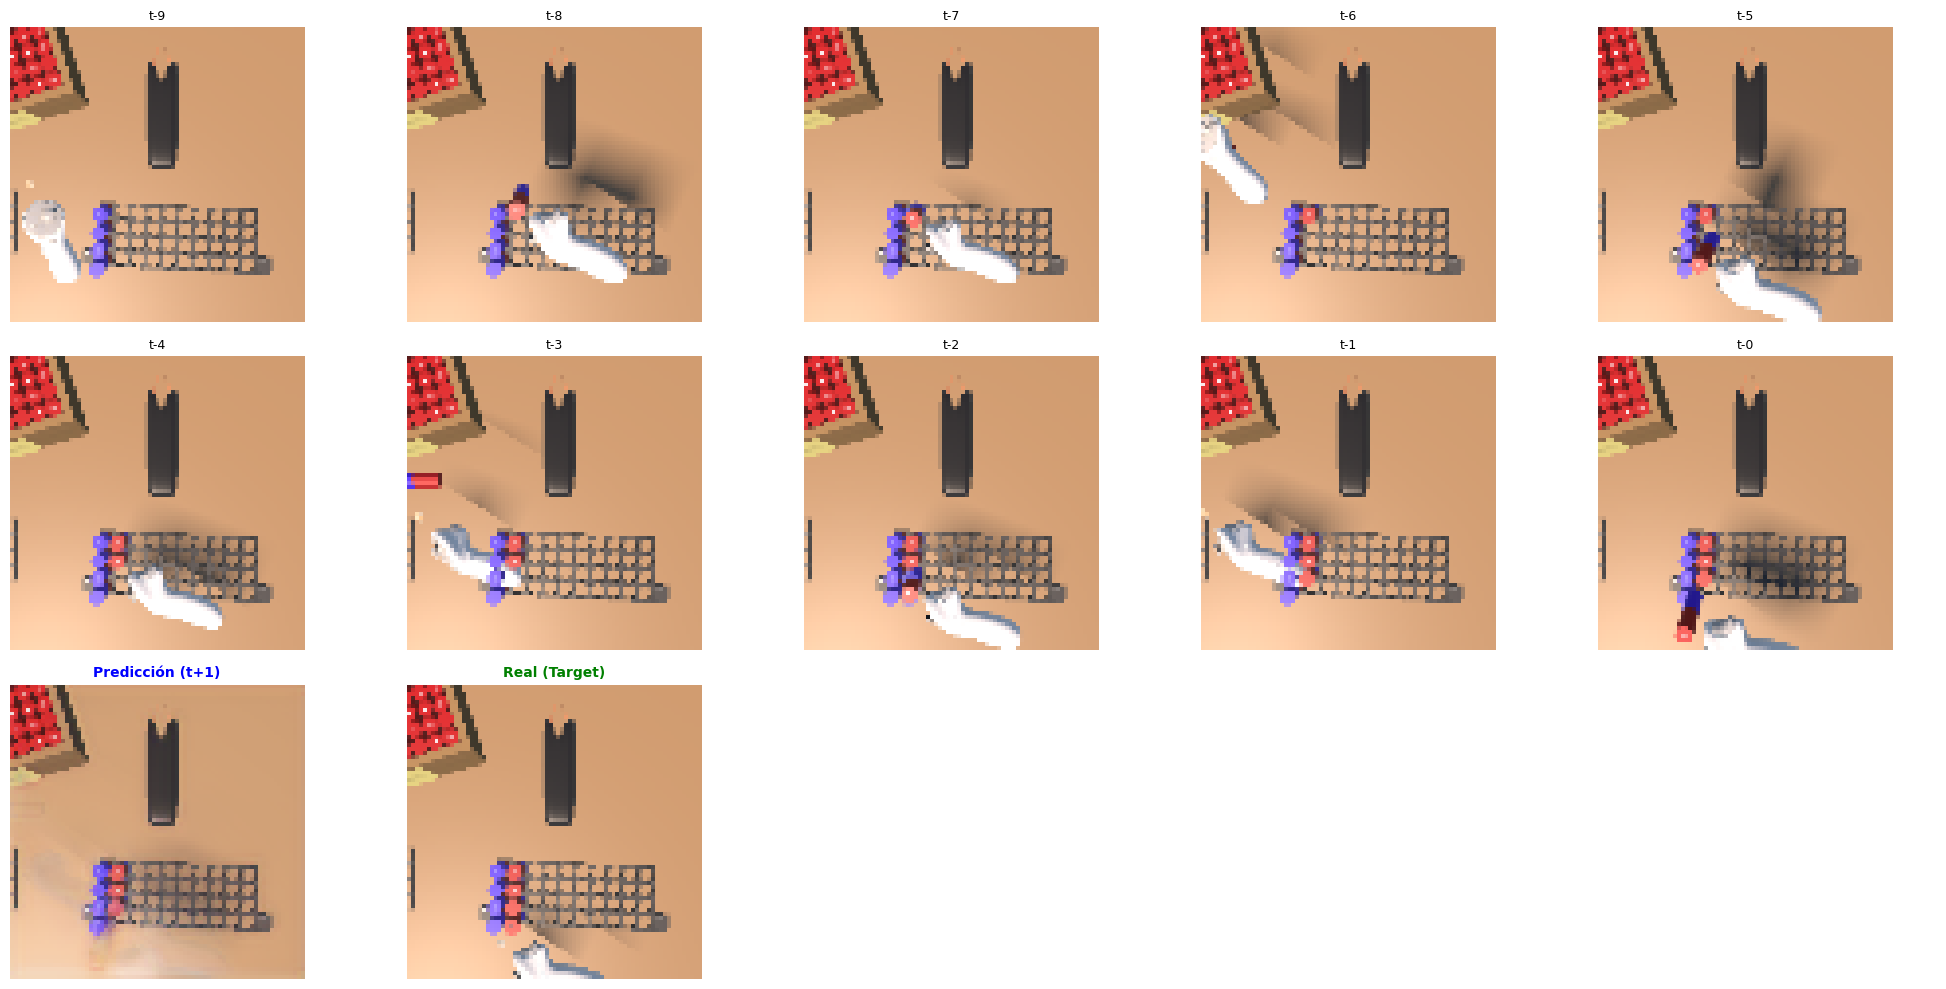

Prediciendo imagen 28 de session_001


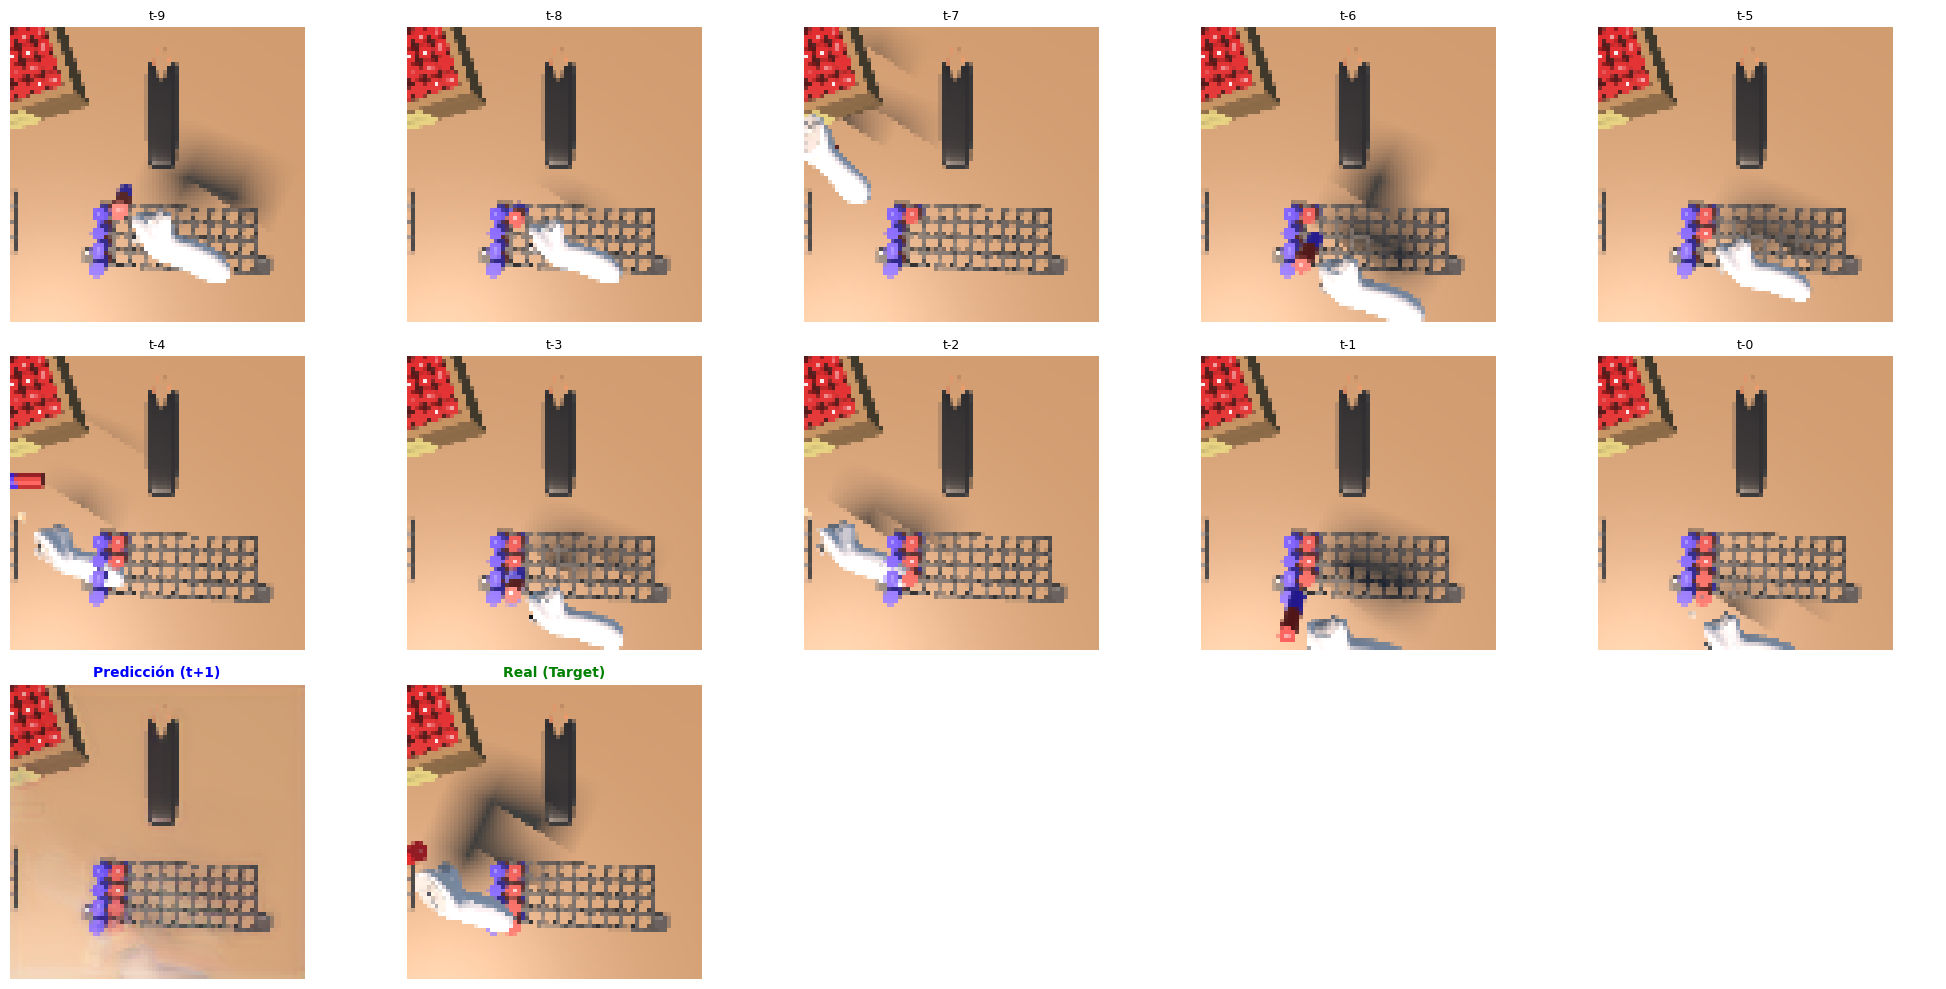

Prediciendo imagen 29 de session_001


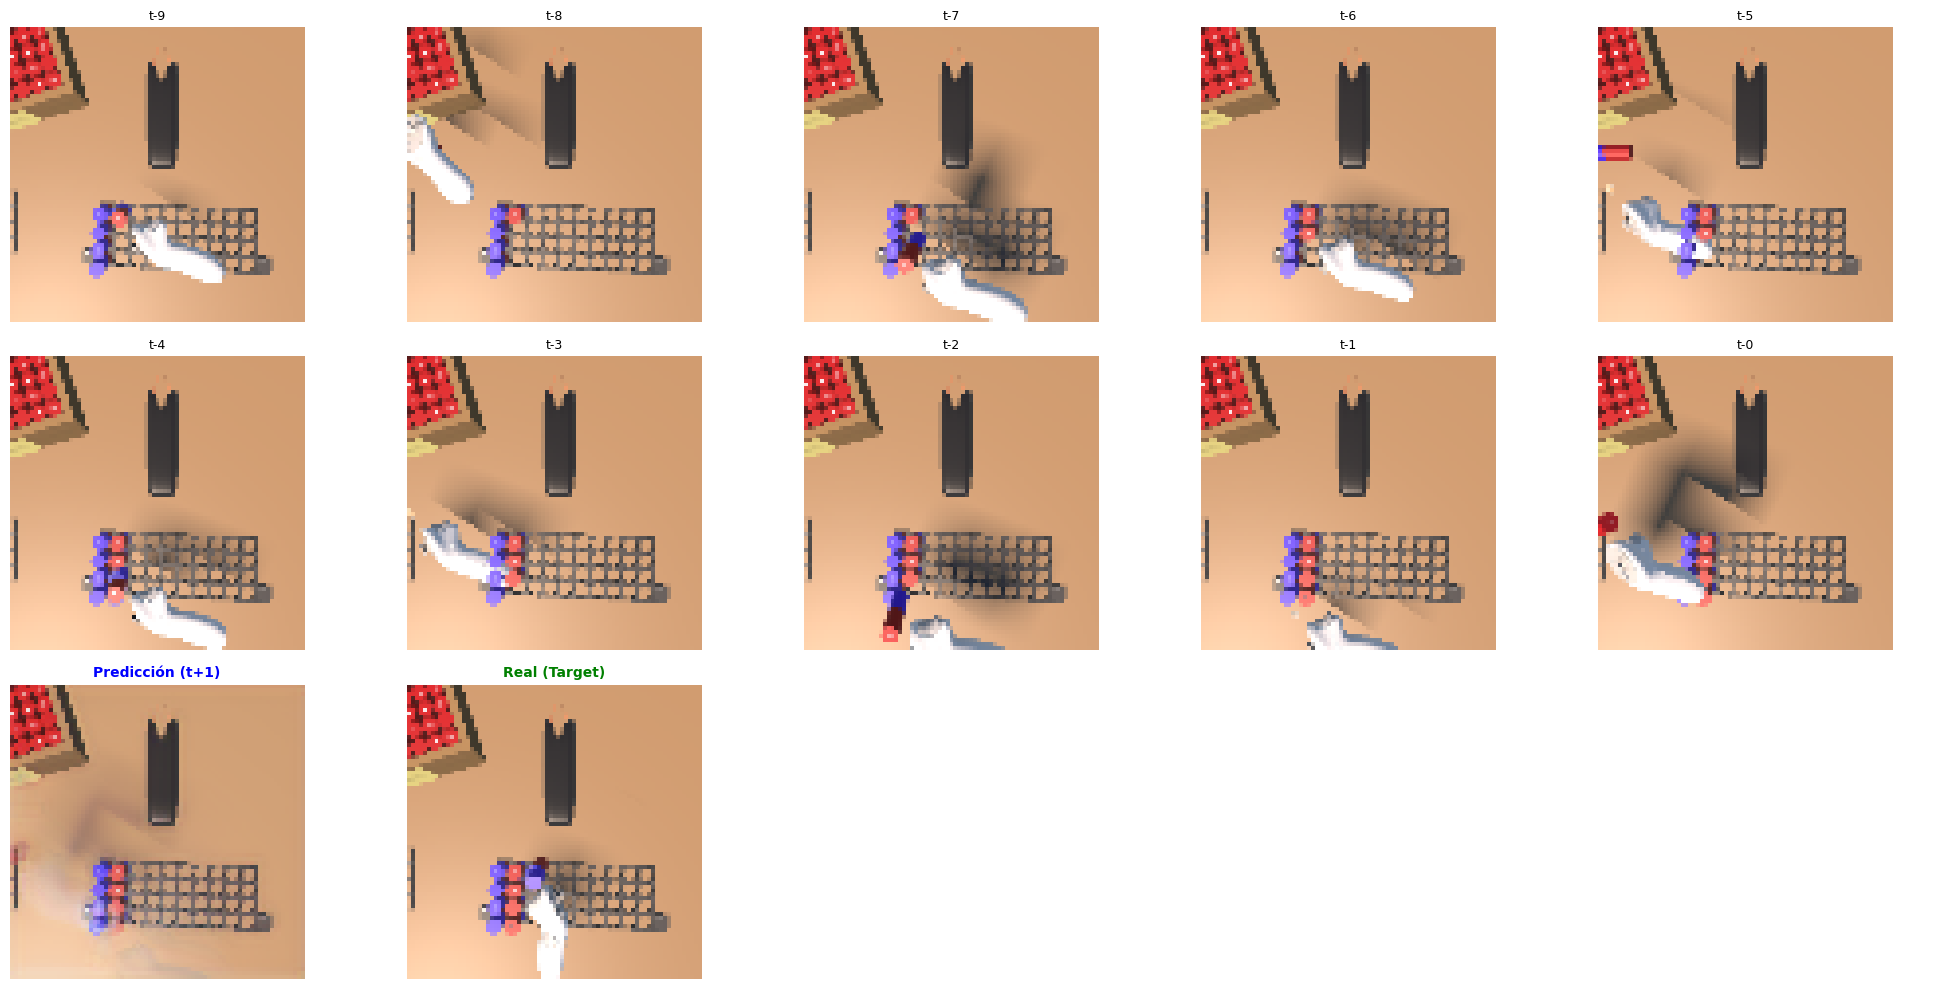

Prediciendo imagen 30 de session_001


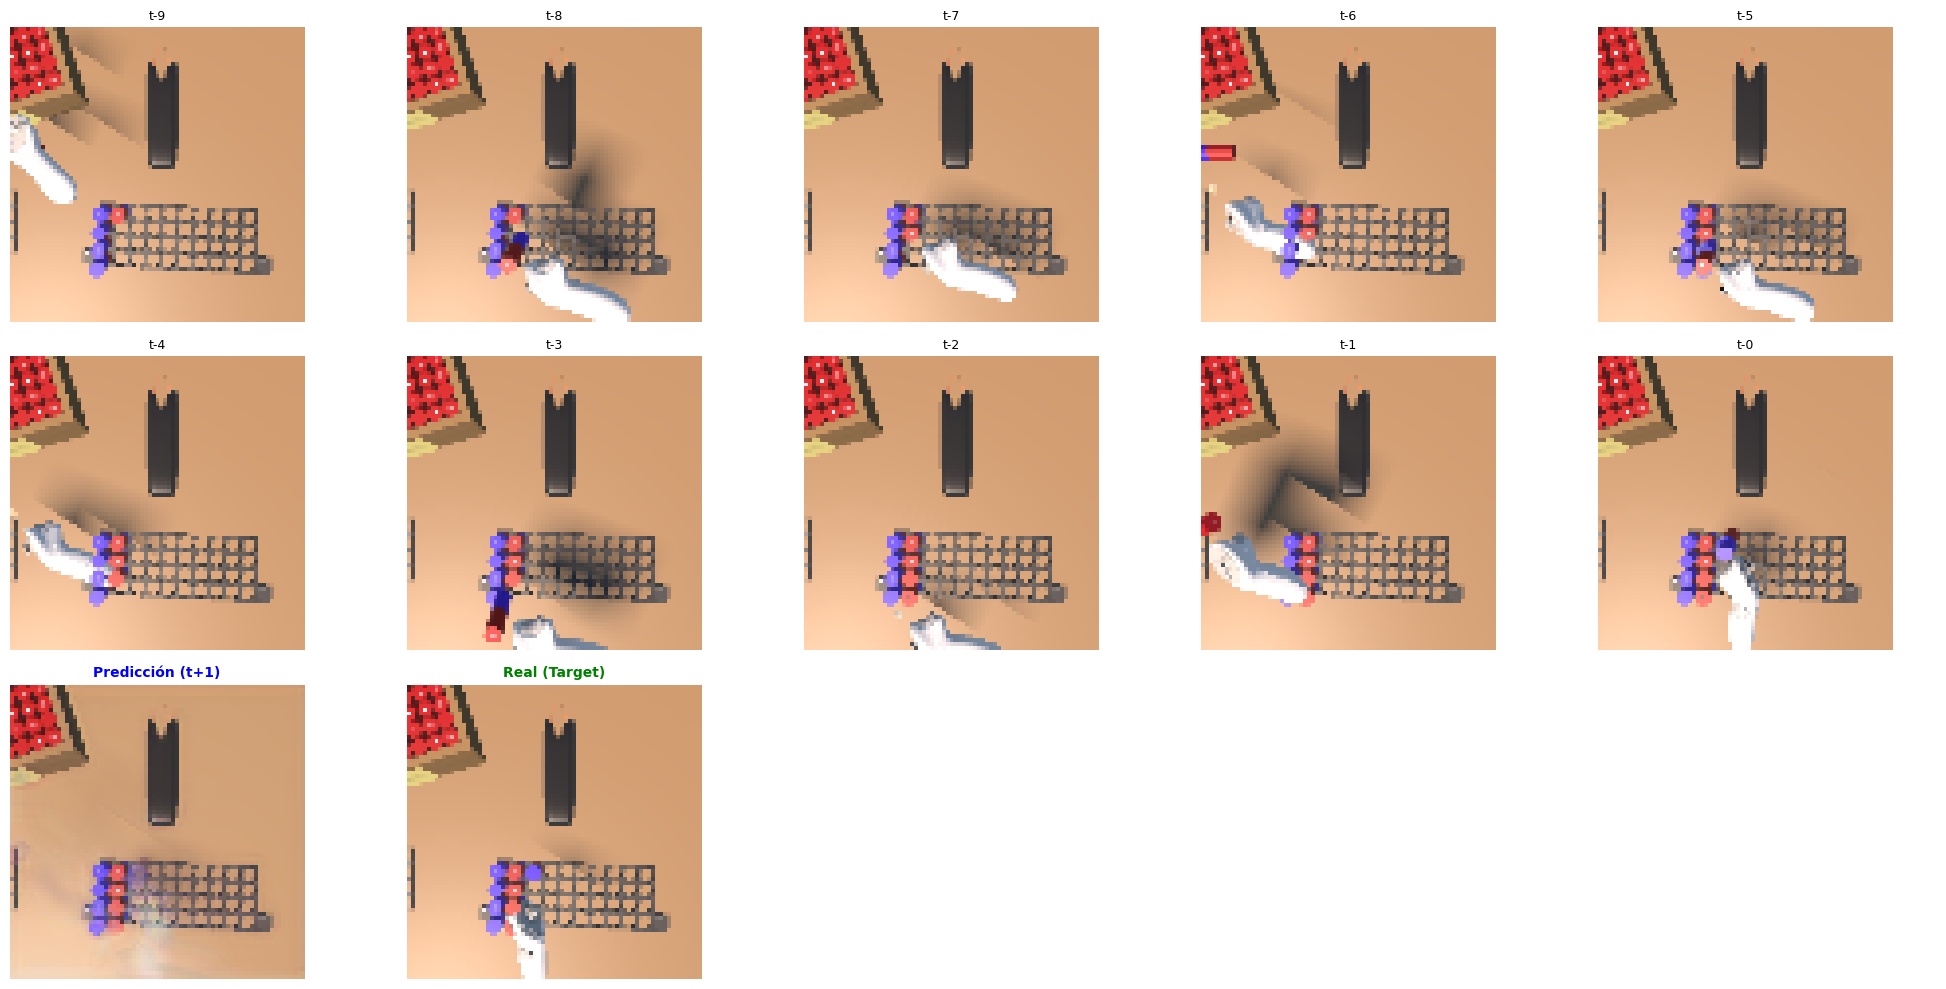

: 

In [ ]:
for i in range(window_size, window_size+21):   
    # la imagen 124 de la sesión 1 es la úlima imagen de la fase "colocarPila"
    fin = i
    print(f"Prediciendo imagen {i} de session_001")
    img_pred, used_imgs = predict_next(model_00, seq_session['Session_001'], fin-window_size, fin, window_size)

    path_real = seq_session['Session_001'][fin+1]
    img_real = load_img_ts(path_real, size=(img_size, img_size))

    lista_total_imgs = list(used_imgs) + [img_pred, img_real]

    total_imgs = len(used_imgs) + 2
    n_filas = (total_imgs + 4) // 5
    fig, axes = plt.subplots(n_filas, 5, figsize=(window_size*2, window_size))

    axes_flat = axes.flatten()

    for idx in range(total_imgs):
        axes_flat[idx].imshow(lista_total_imgs[idx])
        axes_flat[idx].axis('off')
        
        if idx < window_size:
            #  historial
            axes_flat[idx].set_title(f"t-{window_size - idx - 1}", fontsize=9)
        elif idx == total_imgs - 2:
            # PREDICCIÓN
            axes_flat[idx].set_title("Predicción (t+1)", color='blue', fontweight='bold', fontsize=10)
            for spine in axes_flat[idx].spines.values():
                spine.set_edgecolor('blue')
                spine.set_linewidth(2)
        else:
            # Target Real
            axes_flat[idx].set_title("Real (Target)", color='green', fontweight='bold', fontsize=10)

    for idx in range(total_imgs, len(axes_flat)):
        axes_flat[idx].axis('off')

    plt.tight_layout()
    plt.show()

## CNN + LSTM
https://elektron.fi.uba.ar/index.php/elektron/article/view/130

In [21]:
class Attention_block(layers.Layer):

    def __init__(self, channels = 512, **kwargs):
        super(Attention_block, self).__init__(**kwargs)

        self.channels = channels

        self.mlp4_fc = layers.Dense(128, activation=None)
        self.mlp4_drop = layers.Dropout(0.5)

        self.mlp2_fc = layers.Dense(128, activation=None)
        self.mlp2_drop = layers.Dropout(0.5)

        self.mlp3_fc = layers.Dense(49, activation=None)
        self.mlp3_drop = layers.Dropout(0.5)

    def call(self, inputs):

        esp_features, h_prev = inputs
        
        v_t = layers.GlobalAveragePooling2D()(esp_features)

        out_mlp4 = self.mlp4_drop(self.mlp4_fc(v_t))        # shape = (batch, 128)

        out_mlp2 = self.mlp2_drop(self.mlp2_fc(h_prev))     # shape = (batch, 128)

        comb = tf.nn.tanh(out_mlp4 + out_mlp2)              # shape = (batch, 128)

        out_mlp3 = self.mlp3_drop(self.mlp3_fc(comb))       # shape = (batch, 49)
        w_att = tf.nn.softmax(out_mlp3)

        w_esp = tf.reshape(w_att, [-1, 7, 7, 1])    # 7,7 por el img_size = 224, 224 (7 = 224/32 -> VGG15 tiene 5 capas maxpooling -> 32=2^5)

        features = esp_features * w_esp

        v = tf.reduce_sum(features, axis=[1,2])

        return v

        

In [26]:
def vgg16_lstm(window_size, img_size, num_classes, attention):

    input = layers.Input(shape=(window_size, img_size, img_size, 3))

    cnn = tf.keras.applications.VGG16(include_top=False,
                                      weights = './weights/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5', # pesos preentenados con 224x224, cambiar img_size a 224 o probar sin pesos preenternados
                                      input_shape = (img_size, img_size, 3))
    
    cnn.trainable = False

    carac = layers.TimeDistributed(cnn)(input)

    if not attention:
        # arquitectura base
        h_t = layers.TimeDistributed(layers.Flatten)(carac)

        h_t = layers.LSTM(256, return_sequences=False, dropout=0.5)(h_t)

    else:
        # enfoque con atención
        att_block = Attention_block()
        lstm = layers.LSTMCell(256)

        batch_size = tf.shape(carac)[0]
        h_t = tf.zeros([batch_size, 256])
        c_t = tf.zeros([batch_size, 256])

        temp_seq = tf.unstack(carac, axis=1)

        for features_frame in temp_seq:
        # Calcular el vector de contexto atendido usando el frame actual y el estado h anterior
            vector_contexto = att_block([features_frame, h_t])
            
            # Alimentar la celda LSTM con el contexto espacial enfocado y los estados pasados
            _, [h_t, c_t] = lstm(vector_contexto, states=[h_t, c_t])
        
     
    x = layers.Dropout(0.5)(h_t)
    output_clase = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.models.Model(inputs=input, outputs=output_clase)

In [27]:
from sklearn.model_selection import KFold

sessions = np.array(sessions)

errores_por_fold = []
precision_por_fold = []

k=4
kf = KFold(n_splits=k, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(sessions)):
    print(f"\n" + "="*40)
    print(f" entrenando FOLD {fold + 1} / 4 ")
    print(f"="*40)
    
    # Separar las sesiones en 3 folds de entrenamiento y 1 fold de test
    sess_train = sessions[train_idx].tolist()
    sess_test = sessions[test_idx].tolist()
    
    print(f"Sesiones para entrenar ({len(sess_train)}): {sess_train}")
    print(f"Sesiones para test ({len(sess_test)}): {sess_test}")
    
    train_ds = create_ds(sess_train, seq_session, label_dic, window_size, batch_size, shuffle = True)
    test_ds = create_ds(sess_test, seq_session, label_dic, window_size, batch_size, shuffle = False)

    tf.keras.backend.clear_session()
    
    model = vgg16_lstm(window_size, img_size, n_classes, True)
    
    model.compile(
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=15, 
        verbose=1
    )
    
    scores = model.evaluate(test_ds, verbose=0)
    print(f"\n Resultados del Fold {fold + 1} -> Pérdida: {scores[0]:.4f} - Precisión: {scores[1]:.4f}")
    
    errores_por_fold.append(scores[0])
    precision_por_fold.append(scores[1])



print(f"\n" + "====="*10)
print(f" RENDIMIENTO GLOBAL DE VALIDACIÓN CRUZADA (K=4) ")
print(f"====="*10)
print(f"Precisión media: {np.mean(precision_por_fold)*100:.2f}% (+/- {np.std(precision_por_fold)*100:.2f}%)")
print(f"Pérdida media: {np.mean(errores_por_fold):.4f}")


 entrenando FOLD 1 / 4 
Sesiones para entrenar (7): ['Session_008', 'Session_003', 'Session_009', 'Session_006', 'Session_010', 'Session_005', 'Session_002']
Sesiones para test (3): ['Session_004', 'Session_007', 'Session_001']
Epoch 1/15
730/730 [==============================] - 53s 61ms/step - loss: 0.3107 - accuracy: 0.8921 - val_loss: 0.1532 - val_accuracy: 0.9345
Epoch 2/15
730/730 [==============================] - 48s 59ms/step - loss: 0.1201 - accuracy: 0.9610 - val_loss: 0.1266 - val_accuracy: 0.9502
Epoch 3/15
730/730 [==============================] - 47s 58ms/step - loss: 0.0951 - accuracy: 0.9661 - val_loss: 0.1204 - val_accuracy: 0.9466
Epoch 4/15
730/730 [==============================] - 46s 57ms/step - loss: 0.0906 - accuracy: 0.9678 - val_loss: 0.1334 - val_accuracy: 0.9442
Epoch 5/15
730/730 [==============================] - 46s 58ms/step - loss: 0.0729 - accuracy: 0.9736 - val_loss: 0.1725 - val_accuracy: 0.9502
Epoch 6/15
730/730 [==============================]

In [ ]:
model.save("predictionModels/model_vgg16_lstm.h5")